# 🍷 CLASSIFICAÇÃO DA QUALIDADE DE VINHOS
## Tech Challenge 2 - FIAP | Machine Learning & Feature Engineering

---

**Autora:** [Marília / Fernando / Guilherme]  
**Stack:** Python, pandas, matplotlib, seaborn, scikit-learn, XGBoost, imbalanced-learn  
**Objetivo:** Desenvolver um modelo preditivo para triagem de vinhos de alta qualidade, otimizando o controle de qualidade na indústria vinícola.

---

### Bibliotecas Utilizadas

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (
    train_test_split, GridSearchCV, RandomizedSearchCV, StratifiedKFold
)
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    roc_auc_score, precision_score, recall_score, accuracy_score, roc_curve
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from scipy.stats import randint, uniform
from matplotlib.colors import LinearSegmentedColormap

Obsevações
Por que imblearn.pipeline e não sklearn.pipeline?

O ImbPipeline da biblioteca imbalanced-learn garante que o SMOTE seja aplicado apenas nos dados de treino de cada fold da validação cruzada.  

### Configuraçoes

In [3]:
# PALETA DE CORES OFICIAL

COLORS = {
    'bad': '#C79CFF',    # Roxo claro para ruim/médio
    'good': '#32235B'    # Roxo escuro para bom
}

COR_ESCURA = '#32235B'
COR_M_ESCURA = '#5A3F8A'
COR_MEDIA = '#7B5BAE'
COR_CLARA = '#C79CFF'
COR_MEDIO_CLARO = '#A67CDB'

paleta_5_roxos = [
    '#32235B', '#5A3F8A', '#7B5BAE', '#A67CDB', '#C79CFF'
]

GRADIENTE_HEATMAP = [
    [0.0, '#C79CFF'],
    [0.5, '#FFFFFF'],
    [1.0, '#32235B']
]


cores_modelos = {
    'Gradient Boosting': '#1A0F2E',   # Roxo muito escuro (quase preto)
    'KNN': '#3D2B6B',                  # Roxo escuro
    'Random Forest': '#6B4C9A',        # Roxo médio
    'Regressão Logística': '#9B7BC4',  # Roxo médio-claro
    'SVM': '#C79CFF',                  # Roxo claro
    'XGBoost': '#4A2D7A'               # Roxo arroxeado (diferente do GB)
}


cmap_custom = LinearSegmentedColormap.from_list('paleta_roxa', GRADIENTE_HEATMAP)

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)


### Desafio

Neste desafio, será utilizada a base de dados Wine Quality Dataset, disponível publicamente no Kaggle, que contém informações físico-químicas de diferentes amostras de vinho, como acidez, teor alcoólico, densidade e níveis de dióxido de enxofre. Cada amostra também possui uma nota de qualidade atribuída por especialistas, que será utilizada como variável alvo para o desenvolvimento de modelos de classificação.

**Objetivo:**

Desenvolver um **modelo de classificação capaz de prever a qualidade de um vinho** com base em suas características físico-químicas. Para simplificar o problema, a variável de qualidade deverá ser **transformada em uma classificação binária**, por exemplo:

● Vinho de Alta Qualidade (1): nota ≥ 7

● Vinho de Baixa/Média Qualidade (0): nota < 7

O objetivo é treinar e avaliar modelos de aprendizado de máquina capazes de prever essa classificação a partir das variáveis disponíveis.

O conjunto de dados contém variáveis como:

● Acidez fixa (fixed acidity);

● Acidez volátil (volatile acidity);

● Ácido cítrico (citric acid);

● Açúcar residual (residual sugar);

● Cloretos (chlorides);

● Dióxido de enxofre livre (free sulfur dioxide);

● Dióxido de enxofre total (total sulfur dioxide);

● Densidade (density);

● pH;

● Sulfatos (sulphates);

● Teor alcoólico (alcohol);

● Qualidade do vinho (quality).

### Etapa 1: Compreensã do Problema

O problema foi formulado como uma tarefa de classificação binária supervisionada, onde precisa desenvolver um modelo de classificação binária capaz de prever se um vinho é de alta qualidade (nota ≥ 7) ou de baixa/média qualidade (nota < 7). Essa simplificação permite focar no desafio mais relevante para a indústria: identificar quais vinhos atendem ao padrão de alta qualidade, assim, o modelo visa auxiliar vinícolas na triagem de lotes, redução de custos de análise sensorial e tomada de decisões em tempo real durante a produção.




In [4]:
df = pd.read_csv('/content/WineQT.csv') #carregando o dataset

In [5]:
print('\n PRIMEIRAS LINHAS:')
df.head()


 PRIMEIRAS LINHAS:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


Remoção da coluna Id

Foi removida no começo da analise, porque apenas represem um identificador sequencial atribuido durante a coleta dos dados, sem qualquer relação com as variaveis físico-químicos dos vinho.

Essa coluna poderia trazer ruído no processo de modelagem. A remoção de colunas identificadoras é uma prática padrão em projetos de Machine Learning.

In [6]:
# Retirando a coluna id do DataFrame
df = df.drop(columns=['Id'])

In [7]:
print('\n DIMENSÕES DO DATASET:')
print(f'Linhas: {df.shape[0]}')
print(f'Colunas: {df.shape[1]}')


 DIMENSÕES DO DATASET:
Linhas: 1143
Colunas: 12


In [8]:
print('\n INFORMAÇÕES GERAIS:')
print(df.info())


 INFORMAÇÕES GERAIS:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 107.3 KB
None


In [9]:
print('\n ESTÁTISTICAS DESCRITIVAS:')
print(df.describe())


 ESTÁTISTICAS DESCRITIVAS:
       fixed acidity  volatile acidity  citric acid  residual sugar  \
count    1143.000000       1143.000000  1143.000000     1143.000000   
mean        8.311111          0.531339     0.268364        2.532152   
std         1.747595          0.179633     0.196686        1.355917   
min         4.600000          0.120000     0.000000        0.900000   
25%         7.100000          0.392500     0.090000        1.900000   
50%         7.900000          0.520000     0.250000        2.200000   
75%         9.100000          0.640000     0.420000        2.600000   
max        15.900000          1.580000     1.000000       15.500000   

         chlorides  free sulfur dioxide  total sulfur dioxide      density  \
count  1143.000000          1143.000000           1143.000000  1143.000000   
mean      0.086933            15.615486             45.914698     0.996730   
std       0.047267            10.250486             32.782130     0.001925   
min       0.012000  

In [10]:
# Verificando se existe dados duplicados
print(df.duplicated().sum())

125


Foram identificadas observações duplicadas, a remoção dessas duplicadas foi uma decisão técnica criteriosa, baseada em dois importantes pontos: O primeiro é o risco de Data Leakage, podendo resultar em vazamento de informações entre o conjunto de treino e de teste, caso uma duplicada fosse para o treino e outra para o teste, assim, o modelo estaria testando dados idênticos aos que já havia visto no treinamento. Segundo seria a probabilidade estatística, a probabilidade de dois vinhos distintos apresentarem exatamente os mesmos valores em todas as 11 variáveis físico-química é extremamente baixa, portanto, as duplicatas podem corresponder a erro de medição, registro ou replicação acidental do dataset. É um trade-off aceitável, para garantir a integridade dos dados e prevenção de viés nas avaliações.

In [11]:
# Retirando os dados duplicados

print(f"\n Antes de remover duplicatas: {len(df)} linhas")
df = df.drop_duplicates().reset_index(drop=True)
print(f" Depois de remover duplicatas: {len(df)} linhas")
print(f" Linhas removidas: {df.shape[0] - len(df) + (df.shape[0] - len(df))} duplicatas")


 Antes de remover duplicatas: 1143 linhas
 Depois de remover duplicatas: 1018 linhas
 Linhas removidas: 0 duplicatas


In [12]:
# Sem os dados duplicados
print('\n ESTÁTISTICAS DESCRITIVAS:')
df.describe().T


 ESTÁTISTICAS DESCRITIVAS:


,count,mean,std,min,25%,50%,75%,max
fixed acidity,1018.0,8.288507,1.741324,4.60000,7.100000,7.900000,9.100000,15.90000
volatile acidity,1018.0,0.533541,0.183167,0.12000,0.390000,0.520000,0.645000,1.58000
citric acid,1018.0,0.268802,0.196229,0.00000,0.090000,0.250000,0.420000,1.00000
residual sugar,1018.0,2.524411,1.314850,0.90000,1.900000,2.200000,2.600000,15.50000
chlorides,1018.0,0.087187,0.048506,0.01200,0.070000,0.079000,0.090000,0.61100
free sulfur dioxide,1018.0,15.648821,10.176525,1.00000,7.000000,13.000000,21.000000,68.00000
total sulfur dioxide,1018.0,46.325639,33.123533,6.00000,21.000000,38.000000,62.000000,289.00000
density,1018.0,0.996700,0.001916,0.99007,0.995572,0.996665,0.997827,1.00369
pH,1018.0,3.311503,0.157775,2.74000,3.210000,3.310000,3.400000,4.01000
sulphates,1018.0,0.656817,0.167542,0.33000,0.550000,0.620000,0.720000,2.00000


In [13]:
# A variavel algo, 'qualidade', representa as pontuações discretas de qualidade do vinho atribuídas em uma escala ordinal.
# Compreender sua distribuição é essencial para avaliar o equilíbrio entre as classes e identificar possíveis vieses no conjunto de dados.

df['quality'].unique()

array([5, 6, 7, 4, 8, 3])

In [14]:
# Quantos vinhos têm em cada nota?
quality_counts = df['quality'].value_counts().sort_index()
print(quality_counts)
print('\n Podemos perceber que a têm mais vinhos na classificação 5 e 6, ou seja, vinhos medianos')

quality
3      6
4     33
5    433
6    409
7    122
8     15
Name: count, dtype: int64

 Podemos perceber que a têm mais vinhos na classificação 5 e 6, ou seja, vinhos medianos


In [15]:
# DEFINIR VARIÁVEL ALVO (Classificação Binária)

df['quality_binary'] = (df['quality'] >= 7).astype(int)

print("\n VARIÁVEL ALVO: quality_binary")
print("   • 0 = Baixa/Média Qualidade (nota 3-6)")
print("   • 1 = Alta Qualidade (nota 7-10)")

print("\n DISTRIBUIÇÃO DAS CLASSES:")
print(df['quality_binary'].value_counts())
print(f"\n Vinhos Bons: {df['quality_binary'].mean()*100:.2f}%")
print(f" Vinhos Ruins/Médios: {(1-df['quality_binary'].mean())*100:.2f}%")
print("\n⚠️  PROBLEMA: Dataset DESBALANCEADO (apenas ~14% de vinhos bons)")


 VARIÁVEL ALVO: quality_binary
   • 0 = Baixa/Média Qualidade (nota 3-6)
   • 1 = Alta Qualidade (nota 7-10)

 DISTRIBUIÇÃO DAS CLASSES:
quality_binary
0    881
1    137
Name: count, dtype: int64

 Vinhos Bons: 13.46%
 Vinhos Ruins/Médios: 86.54%

⚠️  PROBLEMA: Dataset DESBALANCEADO (apenas ~14% de vinhos bons)


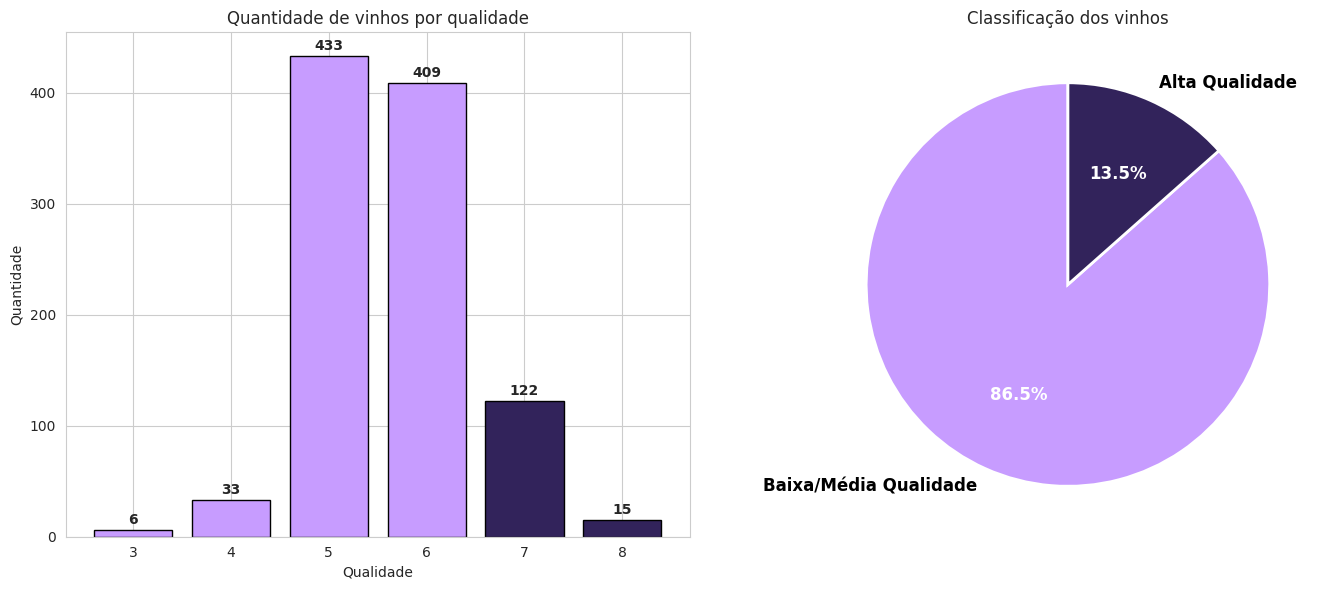

Baixa/Média Qualidade: 881 vinhos
Alta Qualidade: 137 vinhos

 OBSERVAÇÃO IMPORTANTE:
 O dataset está DESBALANCEADO, como vimos nas linhas anteriores.
 Apenas ~13,5% dos vinhos são classificados como "Alta Qualdiade".
 Isso será tratato na etapa de modelagem com técnicas de balanceamento.


In [16]:
# Visualizar distribuição
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# === GRÁFICO DE BARRAS ===
colors_q = ['#32235B' if q >= 7 else '#C79CFF' for q in quality_counts.index]
axes[0].bar(quality_counts.index, quality_counts.values, color=colors_q, edgecolor='black')
axes[0].set_xlabel('Qualidade')
axes[0].set_ylabel('Quantidade')
axes[0].set_title('Quantidade de vinhos por qualidade')

for i, (q, c) in enumerate(zip(quality_counts.index, quality_counts.values)):
    axes[0].text(q, c + 3, str(c), ha='center', va='bottom', fontsize=10, fontweight='bold')

# === GRÁFICO DE PIZZA ===
label_counts = df['quality_binary'].value_counts()

# Capturar os elementos do gráfico de pizza
wedges, texts, autotexts = axes[1].pie(
    label_counts.values,
    labels=['Baixa/Média Qualidade', 'Alta Qualidade'],
    colors=['#C79CFF', '#32235B'],
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 12, 'color': 'black', 'fontweight': 'bold'},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

# MUDAR A COR DAS PORCENTAGENS PARA BRANCO!
for autotext in autotexts:
    autotext.set_color('white')  # Cor branca
    autotext.set_fontsize(12)     # Tamanho da fonte
    autotext.set_fontweight('bold')  # Negrito

axes[1].set_title('Classificação dos vinhos')
plt.tight_layout()
plt.show()

print(f'Baixa/Média Qualidade: {label_counts[0]} vinhos')
print(f'Alta Qualidade: {label_counts[1]} vinhos')

print('\n OBSERVAÇÃO IMPORTANTE:')
print(' O dataset está DESBALANCEADO, como vimos nas linhas anteriores.')
print(' Apenas ~13,5% dos vinhos são classificados como "Alta Qualdiade".')
print(' Isso será tratato na etapa de modelagem com técnicas de balanceamento.')

In [17]:
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,quality_binary
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,0
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,0
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,0
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,0
4,7.4,0.660,0.00,1.8,0.075,13.0,40.0,0.99780,3.51,0.56,9.4,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1013,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,0
1014,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6,0
1015,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,0
1016,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,0


### Etapa 2: Análise Exploratoria dos Dados (EDA)

A primeira etapa consiste em investigar e compreender a distribuição das variáveis, identificar correlação, detectar outliers e analisar o balanceamento das classes.

In [18]:
# Transpõe e arredonda
tabela = df.describe().T.round(3)

# Adiciona uma coluna de "Amplitude" (Max - Min)
tabela['Amplitude'] = (tabela['max'] - tabela['min']).round(3)

# Exibe formatada
print("="*100)
print(" TABELA ESTATÍSTICA DESCRITIVA DAS VARIÁVEIS FÍSICO-QUÍMICAS")
print("="*100)
print(tabela.to_string())
print("="*100)

 TABELA ESTATÍSTICA DESCRITIVA DAS VARIÁVEIS FÍSICO-QUÍMICAS
                       count    mean     std    min     25%     50%     75%      max  Amplitude
fixed acidity         1018.0   8.289   1.741  4.600   7.100   7.900   9.100   15.900     11.300
volatile acidity      1018.0   0.534   0.183  0.120   0.390   0.520   0.645    1.580      1.460
citric acid           1018.0   0.269   0.196  0.000   0.090   0.250   0.420    1.000      1.000
residual sugar        1018.0   2.524   1.315  0.900   1.900   2.200   2.600   15.500     14.600
chlorides             1018.0   0.087   0.049  0.012   0.070   0.079   0.090    0.611      0.599
free sulfur dioxide   1018.0  15.649  10.177  1.000   7.000  13.000  21.000   68.000     67.000
total sulfur dioxide  1018.0  46.326  33.124  6.000  21.000  38.000  62.000  289.000    283.000
density               1018.0   0.997   0.002  0.990   0.996   0.997   0.998    1.004      0.014
pH                    1018.0   3.312   0.158  2.740   3.210   3.310   3.400

In [19]:
# Gerar a tabela descritiva básica
tabela = df.describe().T.round(3)

# Calcular e adicionar a assimetria (skewness)
tabela['Skewness'] = df.skew().round(3)

# Calcular amplitude
tabela['Amplitude'] = (tabela['max'] - tabela['min']).round(3)

# Reordenar colunas (opcional)
tabela = tabela[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max', 'Amplitude', 'Skewness']]

print("="*130)
print("📊 TABELA ESTATÍSTICA DESCRITIVA DAS VARIÁVEIS FÍSICO-QUÍMICAS")
print("="*130)
print(tabela.to_string())
print("="*130)



📊 TABELA ESTATÍSTICA DESCRITIVA DAS VARIÁVEIS FÍSICO-QUÍMICAS
                       count    mean     std    min     25%     50%     75%      max  Amplitude  Skewness
fixed acidity         1018.0   8.289   1.741  4.600   7.100   7.900   9.100   15.900     11.300     1.037
volatile acidity      1018.0   0.534   0.183  0.120   0.390   0.520   0.645    1.580      1.460     0.720
citric acid           1018.0   0.269   0.196  0.000   0.090   0.250   0.420    1.000      1.000     0.369
residual sugar        1018.0   2.524   1.315  0.900   1.900   2.200   2.600   15.500     14.600     4.350
chlorides             1018.0   0.087   0.049  0.012   0.070   0.079   0.090    0.611      0.599     5.933
free sulfur dioxide   1018.0  15.649  10.177  1.000   7.000  13.000  21.000   68.000     67.000     1.172
total sulfur dioxide  1018.0  46.326  33.124  6.000  21.000  38.000  62.000  289.000    283.000     1.680
density               1018.0   0.997   0.002  0.990   0.996   0.997   0.998    1.004      

A Tabela acima apresenta a estatística descritiva das variáveis físico-químicas do dataset. Variáveis como residual sugar e free sulfur dioxide apresentam desvios padrão elevados em relação às suas médias, indicando alta dispersão e a provável presença de outliers.

As variáveis residual sugar, free sulfur dioxide, total sulfur dioxide e chlorides apresentam distribuições assimétricas à direita (skewness > 1), indicando a presença de outliers com valores elevados que puxam a média para cima.

Tabela para explicar Skewness:

| Valor de Skewness | Interpretação | Significa |
| --- | --- | --- |
| -0.5 a 0.5 |  Simétrica | Dados equilibrados em torno da média |
| 0.5 a 1.0| Moderadamente assimétrica à direita | Alguns valores altos puxando a média |
| > 1.0 |  Forte assimetria à direita | 	Muitos outliers altos |
| -0.5 a -1.0| Moderadamente assimétrica à esquerda | Alguns valores baixos puxando a média |
| < -1.0 | Forte assimetria à esquerda | Muitos outliers baixos |



In [20]:
# Lista de features (excluindo as colunas 'quality' e 'quality_binary')
features = [c for c in df.columns if c not in ['quality', 'quality_binary']]


 DISTRIBUIÇÃO DAS VARIÁVEIS
----------------------------------------------------------------------


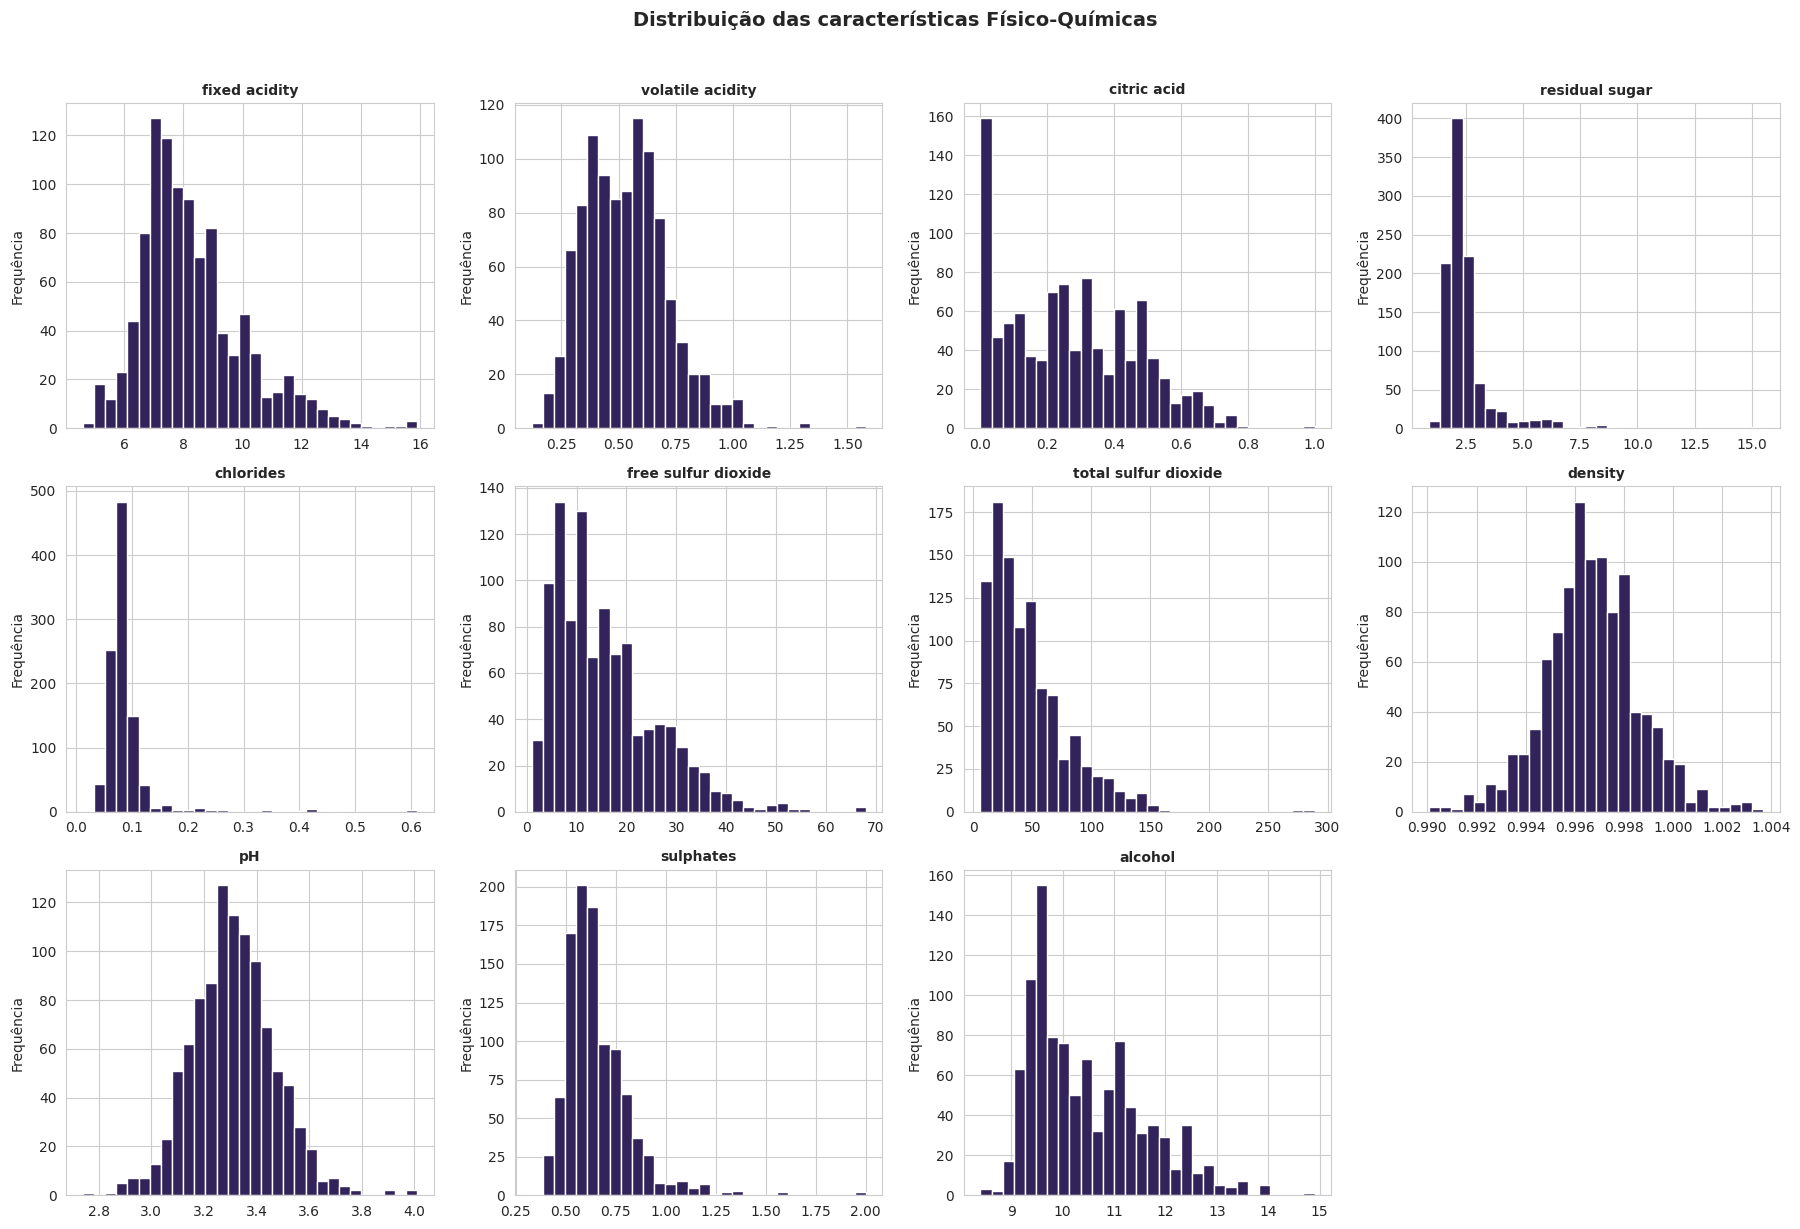

In [21]:
# Distribuição das variáveis
print('\n DISTRIBUIÇÃO DAS VARIÁVEIS')
print('-'*70)

fig, axes = plt.subplots(3, 4, figsize=(18,12))
axes = axes.flatten()

for i, col in enumerate(features):
    df[col].hist(ax=axes[i], color=COR_ESCURA, edgecolor='white', bins=30)
    axes[i].set_title(col, fontweight='bold', fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frequência')


# Esconder subplots vazios
for j in range(len(features), len(axes)):
    axes[j].set_visible(False)


plt.suptitle('Distribuição das características Físico-Químicas',
              fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

O Gráfico **Distribuição das variáveis** apresenta histograma para cada uma das 11 variáveis físico-química dos vinhos, complementando a análise numérica da Tabela anterior. A visualização confirma os padrões identificados nas estatísticas descritivas, que revelava a assimétrica da maioria das variáveis.

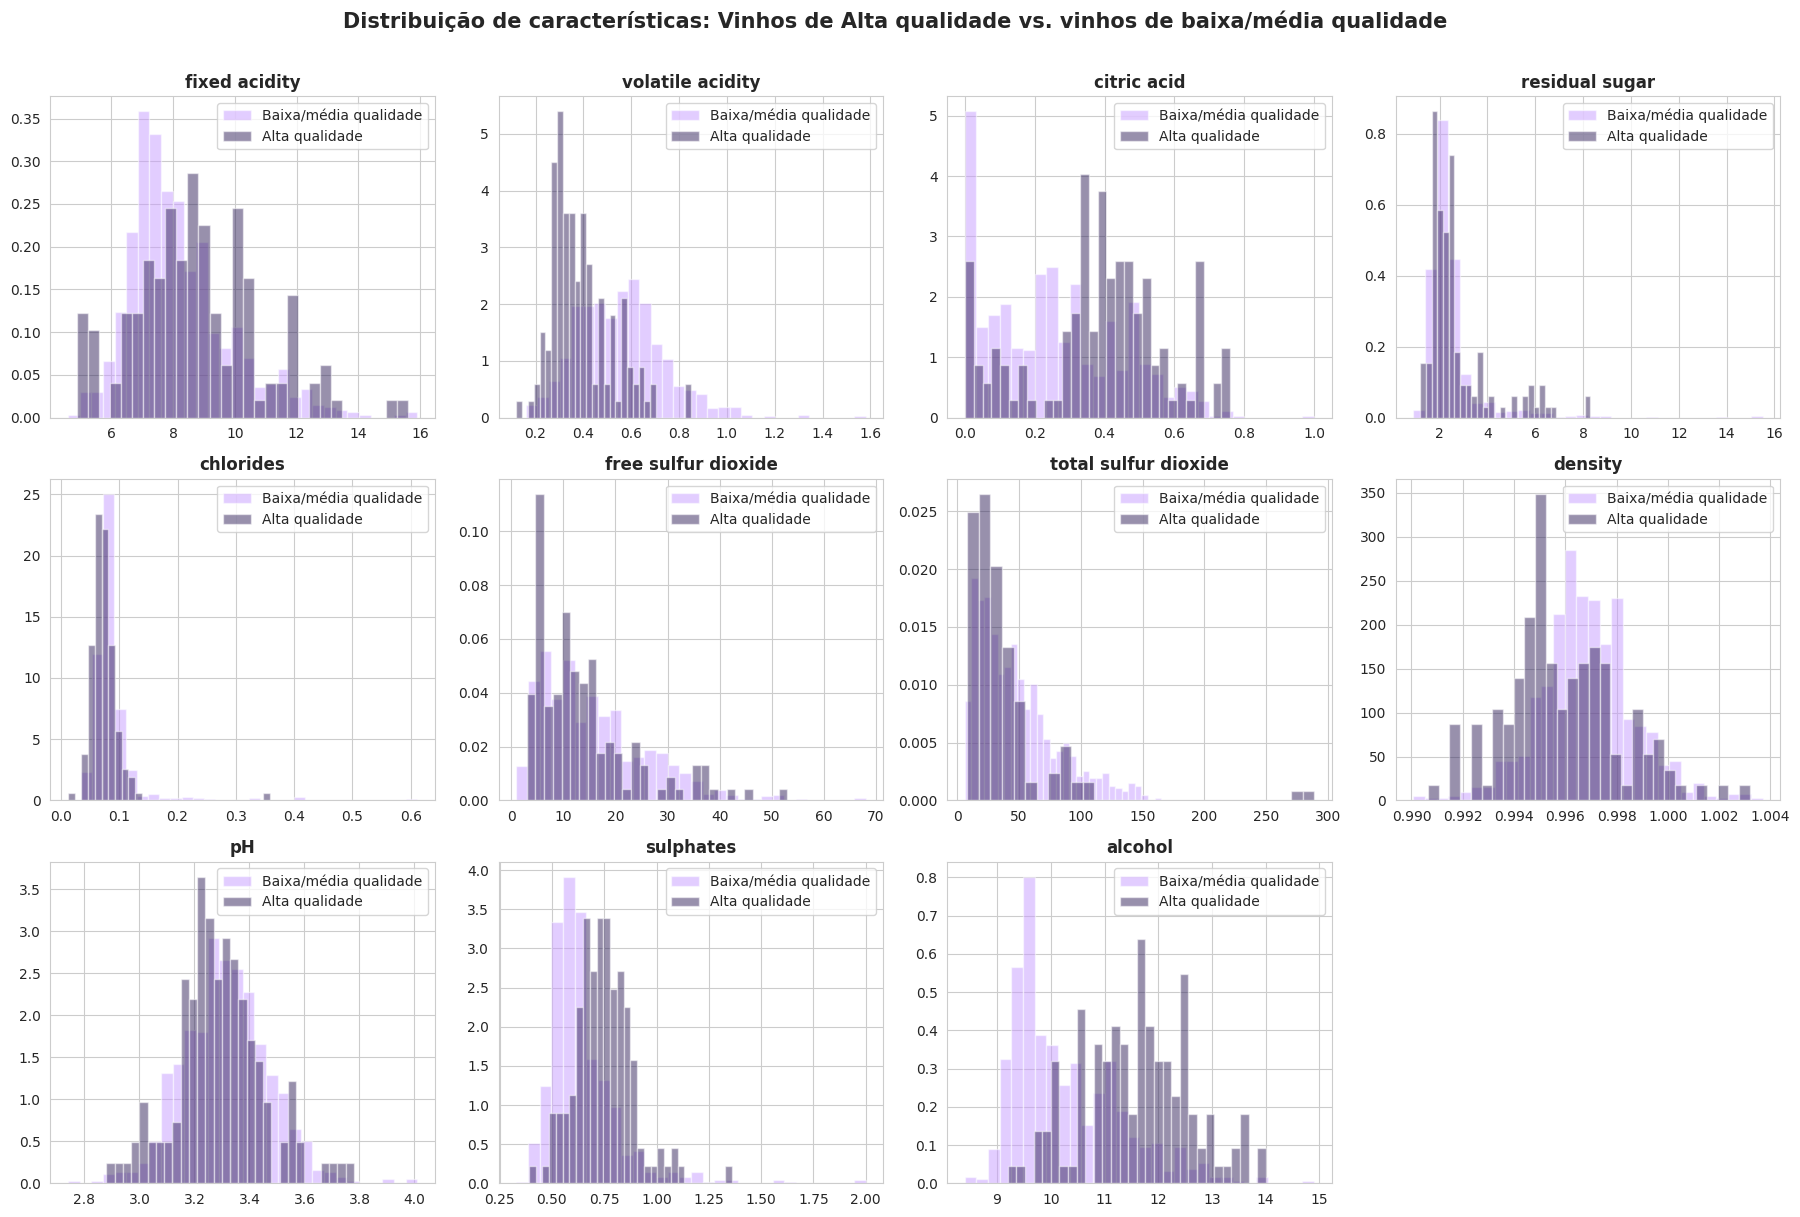

In [22]:
# Distribuição de características por rótulo de qualidade
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes_flat = axes.ravel()

# comparando entre as qualidades de vinhos
for i, col in enumerate(features):
    ax = axes_flat[i]
    for label, color, name in [(0, COLORS['bad'], 'Baixa/média qualidade'),
                              (1, COLORS['good'], 'Alta qualidade')]:
        subset = df[df['quality_binary'] == label][col]
        ax.hist(subset, bins=30, alpha=0.5, color=color, label=name, density=True)
    ax.set_title(col, fontweight='bold', fontsize=12)
    ax.legend(fontsize=10)


for j in range(len(features), len(axes_flat)):
  axes_flat[j].set_visible(False)

fig.suptitle('Distribuição de características: Vinhos de Alta qualidade vs. vinhos de baixa/média qualidade', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

A Figura apresenta a distribuição das 11 características físico-químicas comparando vinhos de alta qualidade (nota ≥ 7) com vinhos de baixa/média qualidade (nota < 7).

Vinhos de alta qualidade apresentam o **alcohol** distribuido entre valores mais elevados (11-14%) em comparação com vinhos de baixa qualidade (9-11%).

Em relação ao **Volatile Acidity**  está concentrada em valores mais baixos (0,2-0,5 g/L) para vinhos de alta qualidade, enquanto vinhos de baixa qualidade apresentam maior dispersão e valores elevados (até 1,2 g/L).

Vinhos de alta qualidade apresentam **sulphates** ligeiramente deslocada para valores mais altos (0,6-0,9) em relação aos vinhos comuns (0,4-0,7).

**Citric Acid**, **Fixed Acidity** e **Density** apresentam distribuição moderada.



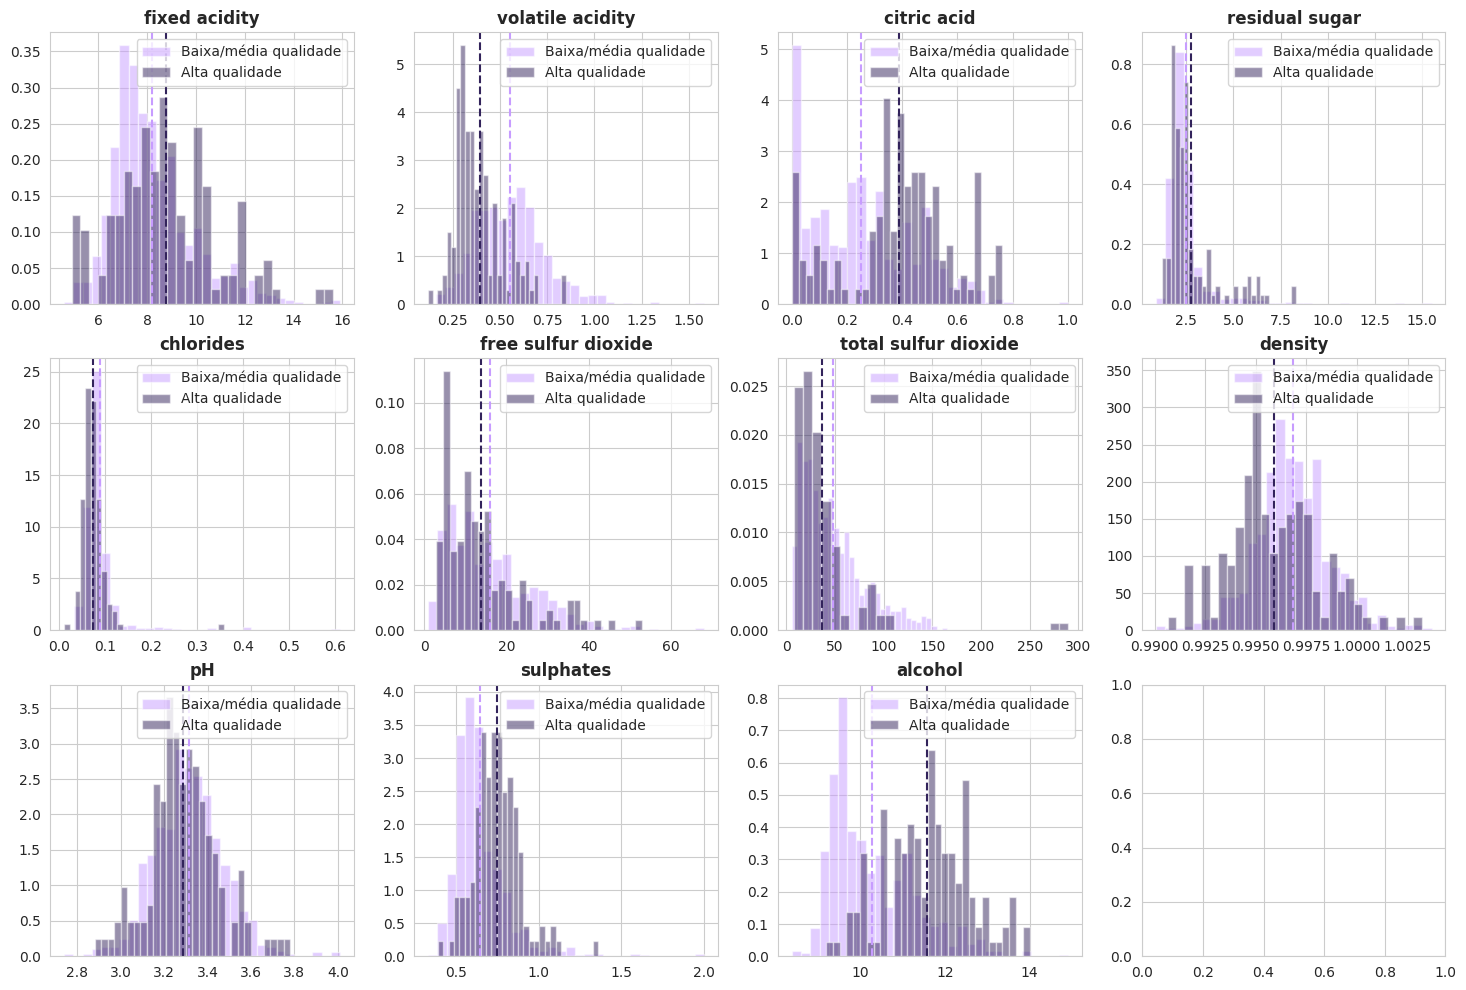

In [23]:
# Distribuição de características por rótulo de qualidade
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes_flat = axes.ravel()

# Adicionar linha vertical na média de cada classe
for i, col in enumerate(features):
    ax = axes_flat[i]
    for label, color, name in [(0, COLORS['bad'], 'Baixa/média qualidade'),
                              (1, COLORS['good'], 'Alta qualidade')]:
        subset = df[df['quality_binary'] == label][col]
        ax.hist(subset, bins=30, alpha=0.5, color=color, label=name, density=True)

        # Adicionar linha da média
        media = subset.mean()
        ax.axvline(media, color=color, linestyle='--', linewidth=1.5)

    ax.set_title(col, fontweight='bold', fontsize=12)
    ax.legend(fontsize=10)

A Figura apresenta a distribuição comparando vinhos de alta qualidade (nota ≥ 7, representados em roxo escuro) com vinhos de baixa/média qualidade (nota < 7, em roxo claro). As linhas tracejadas verticais indicam a média de cada classe, facilitando a visualização da separação entre os grupos.

A visualização confirma que a qualidade do vinho está fortemente associada a um perfil físico-químico específico: **maior teor alcoólico, menor acidez volátil e maior concentração de sulfatos**.


 Heatmap de Correlação entre Features


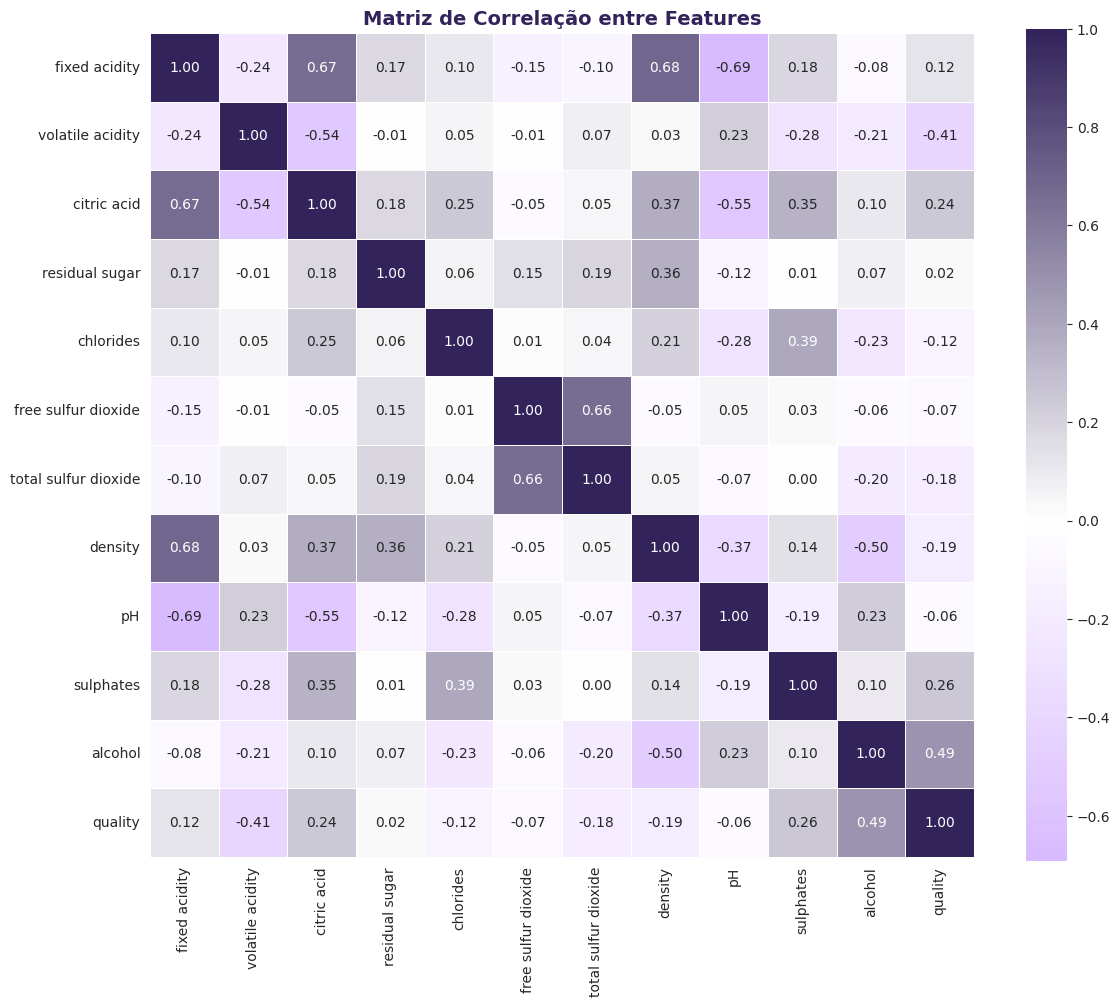

In [24]:
# Heatmap de correlação
print("\n Heatmap de Correlação entre Features")
corr_matrix = df[features + ['quality']].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap=cmap_custom,
            center=0,
            linewidths=0.5,
            linecolor='white',
            square=True)
plt.title('Matriz de Correlação entre Features',
          fontsize=14, fontweight='bold', color=COR_ESCURA)
plt.tight_layout()
plt.show()


 Matriz de correlação de Pearson entre as variáveis físico-químicas e a qualidade do vinho. Tons de roxo escuro indicam correlação positiva; tons de roxo claro indicam correlação negativa.

 Por que usar a correlação de Pearson? Porque mede a relação linear entre variáveis. Valores próximos de +1 ou -1 indicam correlação forte. Mas correlação ≠ causalidade! Duas variáveis podem estar correlacionadas sem uma causar a outra.


 Correlações com a Qualidade


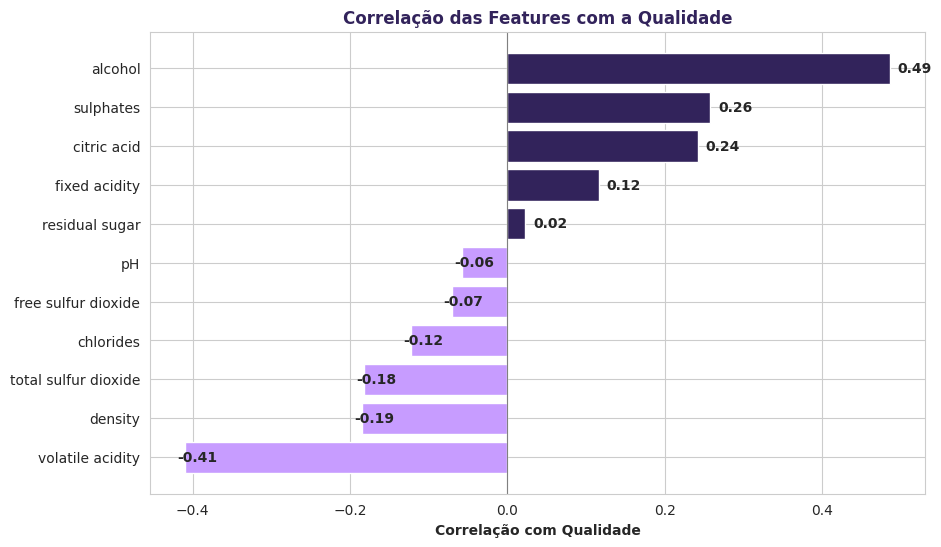

In [25]:
# Correlações com a Qualidade

print("\n Correlações com a Qualidade")
corr_with_quality = df[features + ['quality']].corr()['quality'].drop('quality').sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
colors_corr = [COLORS['good'] if c > 0 else COLORS['bad'] for c in corr_with_quality]
ax.barh(corr_with_quality.index, corr_with_quality.values,
        color=colors_corr, edgecolor='white')
ax.axvline(0, color='gray', linewidth=0.8)
ax.set_xlabel('Correlação com Qualidade', fontweight='bold')
ax.set_title('Correlação das Features com a Qualidade',
             fontweight='bold', color=COR_ESCURA)

for i, (feat, val) in enumerate(corr_with_quality.items()):
    ax.text(val + 0.01 * np.sign(val), i, f'{val:.2f}',
            va='center', fontsize=10, fontweight='bold')

Tons de roxo escuro indicam correlação positiva; tons de roxo claro indicam correlação negativa.


 2.3: Detecção de Outliers


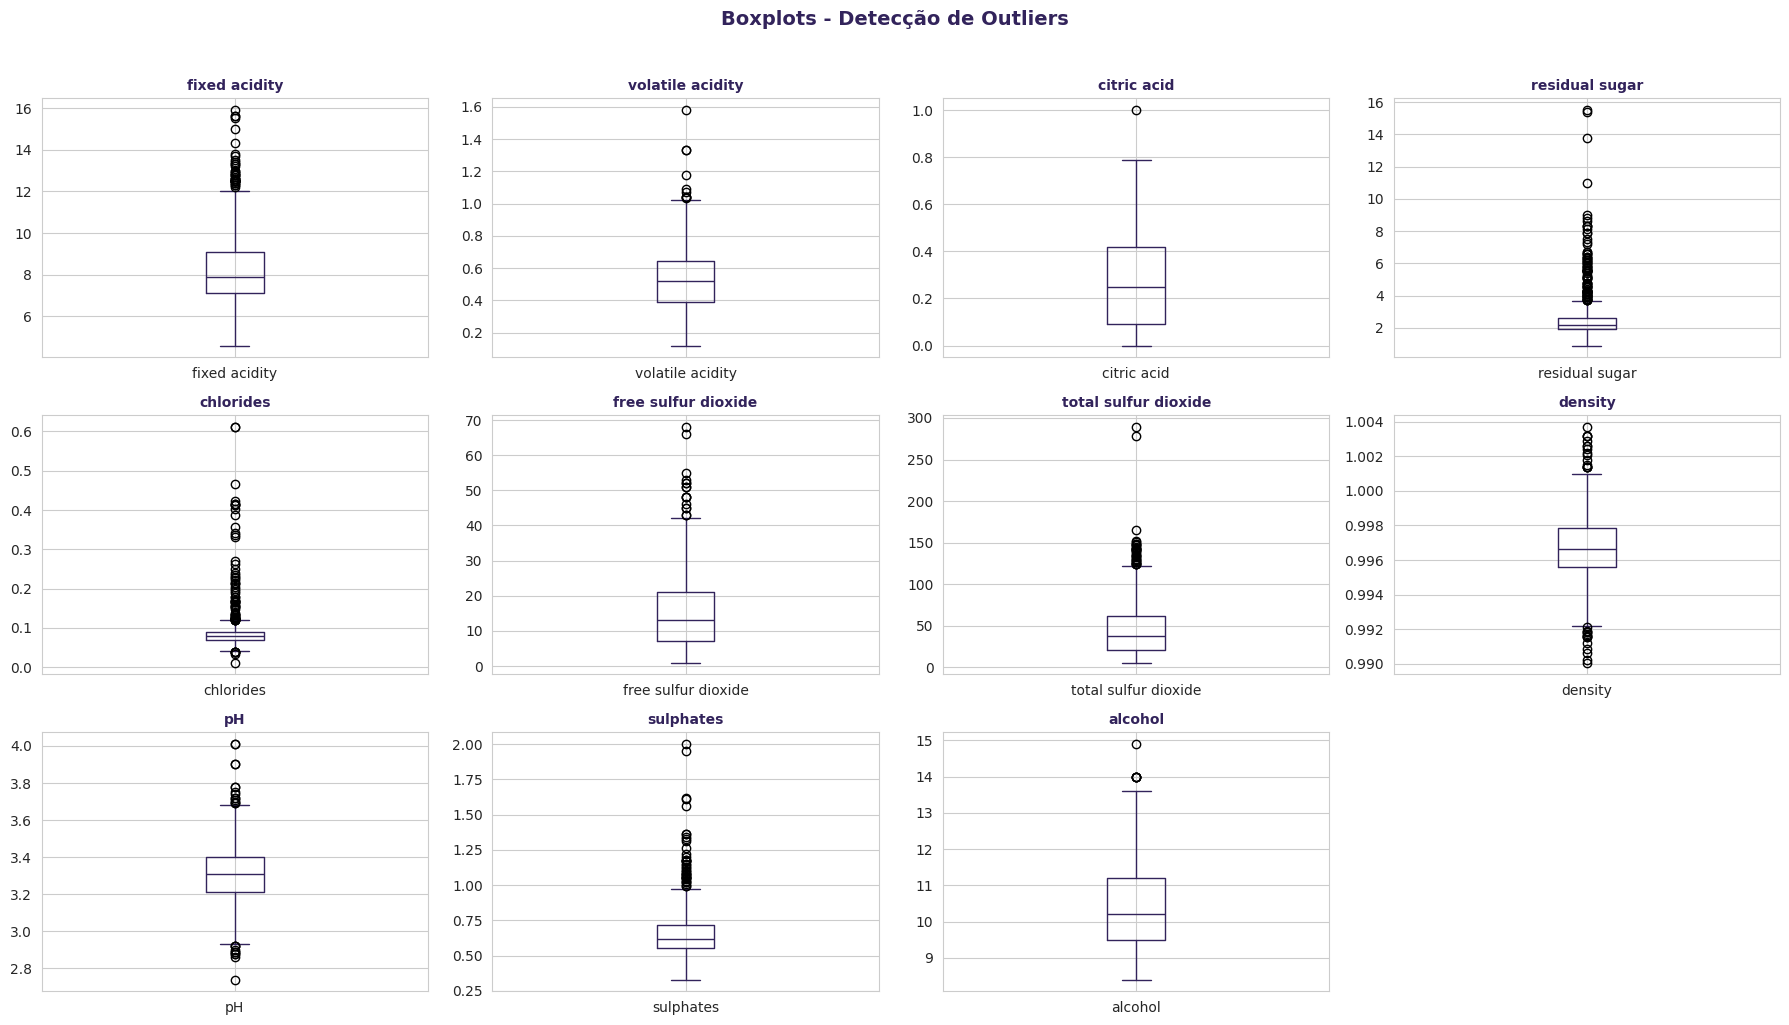

In [26]:
# 2.3: Outliers (Boxplots)

print("\n 2.3: Detecção de Outliers")
fig, axes = plt.subplots(3, 4, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(features):
    df.boxplot(column=col, ax=axes[i], color=COR_ESCURA)
    axes[i].set_title(col, fontweight='bold', fontsize=10, color=COR_ESCURA)
    axes[i].set_ylabel('')

for j in range(len(features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots - Detecção de Outliers',
             fontsize=14, fontweight='bold', color=COR_ESCURA, y=1.02)
plt.tight_layout()
plt.show()

Boxplots das variáveis físico-químicas para detecção de outliers (pontos fora dos bigodes). Destacam-se outliers em chlorides, total sulfur  dioxide e residual suga.

Ao invés de remover os outliers, o que iria fazer perder informações valiosas, será tratado na normalização, no processo de pré-processamento.


 2.4: Análise de Balanceamento


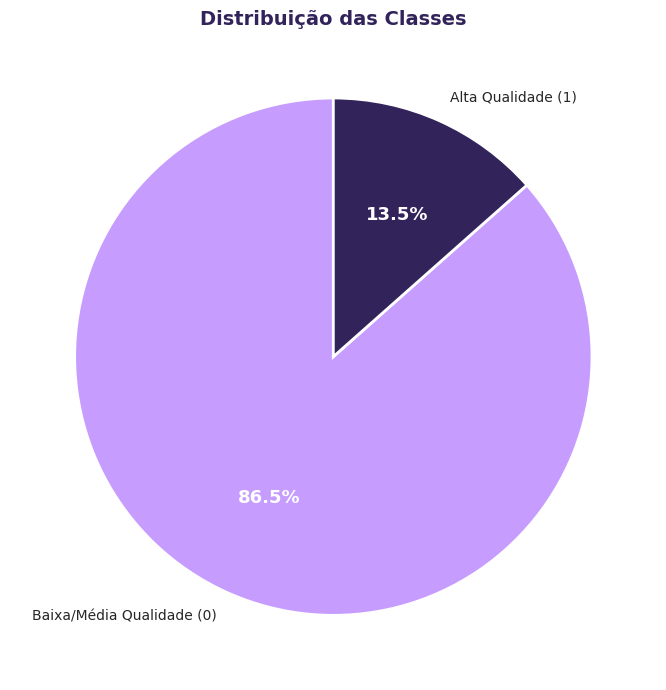

In [27]:
# Balanceamento das Classes

print("\n 2.4: Análise de Balanceamento")
fig, ax = plt.subplots(figsize=(7, 7))

label_counts = df['quality_binary'].value_counts()
wedges, texts, autotexts = ax.pie(
    label_counts.values,
    labels=['Baixa/Média Qualidade (0)', 'Alta Qualidade (1)'],
    colors=[COLORS['bad'], COLORS['good']],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(13)
    autotext.set_fontweight('bold')

ax.set_title('Distribuição das Classes',
             fontsize=14, fontweight='bold', color=COR_ESCURA)
plt.tight_layout()
plt.show()

A variável alvo (quality_binary) apresenta desbalanceamento significativo, como pode ser observado no Gráfico 1, apenas 13,5% das amostras são de alta qualidade. Para mitigar esse problema, foram testadas três estratégias de balanceamento: SMOTE (oversampling sintético), class_weight (ponderação de classes) e a combinação de ambas."

•	**SMOTE** (*Synthetic Minority Over-sampling Technique*): gera amostras sintéticas da classe minoritária (alta qualidade), intercalando os vizinhos mais próximos, modificando fisicamente o dataset.

•	**Class_Weight = 'balanced'**: atribui pesos maiores aos erros cometidos na classe minoritária durante o tratamento, sem modificar os dados originais.

•	**SMOTE + Class_Weight = 'balanced'**: combina ambas as abordagens, oferecendo dupla proteção contra o desbalanceamento.


### Etapa 3: Préprocessamento de Dados

In [28]:
# 3.1: Dados Faltantes

print("\n 3.1: Verificação de Dados Faltantes")
missing = df.isnull().sum()
if missing.sum() == 0:
    print(" Nenhum dado faltante encontrado!")
else:
    print(f" Dados faltantes: {missing[missing > 0]}")


 3.1: Verificação de Dados Faltantes
 Nenhum dado faltante encontrado!


In [29]:
# 3.2: Feature Engineering (Novas Variáveis)
#Com base na análise de correlações, foram criados três features para capturar as interações não-lineares entre as variáveis:

print("\n 3.2: Criação de Novas Features")

df['alcohol_volatile_ratio'] = df['alcohol'] / (df['volatile acidity'] + 0.001)
df['sulphates_alcohol_product'] = df['sulphates'] * df['alcohol']
df['acidity_balance'] = df['citric acid'] - df['volatile acidity']

print(" alcohol_volatile_ratio (álcool/acidez volátil)")
print(" sulphates_alcohol_product (sulfatos × álcool)")
print(" acidity_balance (ácido cítrico - acidez volátil)")


 3.2: Criação de Novas Features
 alcohol_volatile_ratio (álcool/acidez volátil)
 sulphates_alcohol_product (sulfatos × álcool)
 acidity_balance (ácido cítrico - acidez volátil)


•	**alcohol_volatile_ratio** (Razão Álcool/Acidez Volátil): Calculado como alcohol / volatile_acidity, captura o equilíbrio entre os dois fatores mais influentes na qualidade do vinho. O álcool com uma relação positiva (0.49) e a acidez volátil com uma relação negativa (0,41). Essa feature sintetiza um trade-off entre qualidade (álcool) e o defeito (acidez volátil).

•	**sulphates_alcohol_product** (Interação Sulfatos-Álcool): Calculada como sulphates × alcohol, captura a interação entre dois fatores positivos. Os sulfatos atuam como conservantes naturais (0,26), enquanto o álcool contribui para o corpo e estrutura do vinho (0,49). O produto entre essas variáveis representa vinhos que combinam boa conservação com estrutura alcoólica adequada.  

•	**acidity_balance** (Balanço de Acidez): Calculada como citric_acid - volatile_acidity, diferença entre ácido cítrico e acidez volátil. O ácido cítrico está associado ao frescor e equilíbrio do sabor (com correlação positiva de 0,24), enquanto a acidez volátil elevada indica oxidação ou contaminação (com correlação negativa de 0,41). Valores positivos indicam predominância de acidez benéfica, enquanto valores negativos sugerem defeitos no vinho.

Foram ciradas essas novas features para capturar interações não-lineares entre as variáveis.


Para avaliar o impacto da seleção de variáveis no desempenho dos modelos, foram definidos dois cenários:

1.	**Features Originais** (11 variáveis): todas as variáveis do dataset original;

2.	**Com Engenharia** (14 variáveis): features originais + as 3 novas features criadas.

3.	**Features mais correlacionadas** (5 variáveis): top 5 variáveis correlacionadas com a qualidade (alcohol, volatile acidity, sulphates, citric acid e density).

Por que 3 cenários? Para validar empiricamente se o feature engineering ajudou ou atrapalhou.

In [30]:
# 3.3: Definir os 3 Cenários de Features

print("\n📊 3.3: Definindo Cenários de Features")

features_originais = ['fixed acidity', 'volatile acidity', 'citric acid',
                      'residual sugar', 'chlorides', 'free sulfur dioxide',
                      'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']

features_com_engenharia = features_originais + [
    'alcohol_volatile_ratio', 'sulphates_alcohol_product', 'acidity_balance'
]

corr = df[features_originais + ['quality']].corr()['quality'].drop('quality')
top5_corr = corr.abs().sort_values(ascending=False).head(5).index.tolist()
print(f"   🏆 Top 5 features mais correlacionadas: {top5_corr}")
features_top5 = top5_corr

cenarios_features = {
    'Originais (11)': features_originais,
    'Com Engenharia (14)': features_com_engenharia,
    'Top 5 Correlacionadas': features_top5
}


📊 3.3: Definindo Cenários de Features
   🏆 Top 5 features mais correlacionadas: ['alcohol', 'volatile acidity', 'sulphates', 'citric acid', 'density']


Os dados foram divididos em treino (80%) com 814 amostras e teste (20%) com 204 amostras, utilizando a função train_test_split, utilizando o parâmetro stratify=y, para manter a proporção das classes, Sem estratificação, poderia haver folds sem nenhum vinho bom, quebrando a validação cruzada.

In [31]:
# 3.4: Split (ANTES de qualquer escalonamento!)

print("\n 3.4: Divisão Treino/Teste")
X = df[features_com_engenharia]
y = df['quality_binary']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"   Treino: {len(X_train)} amostras ({len(X_train)/len(df)*100:.1f}%)")
print(f"   Teste: {len(X_test)} amostras ({len(X_test)/len(df)*100:.1f}%)")
print(f"   Bons no treino: {y_train.mean()*100:.1f}%")
print(f"   Bons no teste: {y_test.mean()*100:.1f}%")



 3.4: Divisão Treino/Teste
   Treino: 814 amostras (80.0%)
   Teste: 204 amostras (20.0%)
   Bons no treino: 13.5%
   Bons no teste: 13.2%


Por que split **antes** do escalonamento? Porque causa DATA LEAKAGE! Se você escalonar antes de dividir, a média/desvio padrão do teste "vaza" para o treino.

O escalonamento das variáveis é uma etapa importante, pois modelos baseados em distância ou em gradientes, são sensíveis à magnitude das features. Foram testados dois escalonamentos:

•	**StandardScaler:** padroniza as features subtraindo a média e dividindo pelo desvio padrão, resultando em distribuição com média igual a zero e desvio padrão igual a um. Porém, é um método sensível a outliers, pois a média e o desvio padrão pode ser significativamente distorcidas por valores extremos;

•	**RobustScaler:** padroniza as features subtraindo a mediana e dividindo pelo intervalo interquartil (IQR - diferença entre o terceiro e o primeiro quartil). Como a mediana e o IQR são estatísticas robustas (não influenciadas por valores que fogem do comum), esse escalonador é mais adequado para datasets com outliers.


In [32]:
# Definir Escaladores

print("\n 3.5: Definindo Escaladores")
escaladores = {
    'StandardScaler': StandardScaler(),
    'RobustScaler': RobustScaler()
}
print("   StandardScaler (média=0, desvio=1)")
print("   RobustScaler (mediana=0, IQR=1) - resistente a outliers")


 3.5: Definindo Escaladores
   StandardScaler (média=0, desvio=1)
   RobustScaler (mediana=0, IQR=1) - resistente a outliers


### Etapa 4 - Desenvolvmento de modelos

"Como será testado múltiplas combinações de cenários, escalonamento e estratégia de balanceamento foi escolhido a abordagem RandomizedSearchCV ao invés de GridSearchCV."

Foram selecionados seis algoritmos de classificação, que abrangem diferentes abordagens de aprendizado. Entre eles tem modelos baseados em Árvores (Random Forest, XGBoost e Gradient Boosting), modelos baseados em distância (KNN e SVM) e modelo linear (Regressão Logística):

•	**Random Forest**: combina múltiplas árvores de decisão, oferecendo robustez a outliers;

•	**Gradient Boosting**: algoritmo sequencial que constrói árvores para corrigir erros das anteriores, capturando padrões complexos;

•	**XGBoost**: execução otimizada de Gradient Boosting, apresentando alta performance em dados tabulares;

•	**KNN** (*K-Nearest Neighbors*): classificação baseada em vizinhos mais próximos, sensível a outliers;

•	**SVM** (*Support Vector Machine*): máquina de vetores de suporte, capaz de lidar com relações não-lineares;

•	**Regressão Logística**: modelo linear probabilístico.

Essa diversidade permite avaliar diferentes modelos de aprendizagem e identificar qual abordagem é mais adequada.


In [33]:
print(" ETAPA 4: DESENVOLVIMENTO DE MODELOS")

# 4.1: Definir os 6 Modelos

modelos = {
    'Random Forest': RandomForestClassifier(random_state=42, n_jobs=-1),
    'KNN': KNeighborsClassifier(),
    'Regressão Logística': LogisticRegression(random_state=42, max_iter=1000),
    'SVM': SVC(random_state=42, probability=True),
    'XGBoost': XGBClassifier(random_state=42, verbosity=0, use_label_encoder=False, eval_metric='logloss'),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

 ETAPA 4: DESENVOLVIMENTO DE MODELOS


In [34]:
# 4.2: Definir Estratégias de Balanceamento

estrategias_balanceamento = {
    'SMOTE': {'has_class_weight': False},
    'class_weight': {'has_class_weight': True},
    'SMOTE + class_weight': {'has_class_weight': True}
}

In [35]:
# 4.3: Grid de Hiperparâmetros

param_grids = {
    'Random Forest': {
        'modelo__n_estimators': [100, 200],
        'modelo__max_depth': [10, 20, None],
        'modelo__min_samples_split': [2, 5]
    },
    'KNN': {
        'modelo__n_neighbors': [3, 5, 10, 15],
        'modelo__weights': ['uniform', 'distance'],
        'modelo__metric': ['euclidean', 'manhattan']
    },
    'Regressão Logística': {
        'modelo__C': [0.01, 0.1, 1, 10],
        'modelo__penalty': ['l2'],
        'modelo__solver': ['lbfgs']
    },
    'SVM': {
        'modelo__C': [0.1, 1, 10],
        'modelo__kernel': ['rbf', 'linear'],
        'modelo__gamma': ['scale', 'auto']
    },
    'XGBoost': {
        'modelo__n_estimators': [100, 200],
        'modelo__max_depth': [3, 5, 7],
        'modelo__learning_rate': [0.01, 0.1]
    },
    'Gradient Boosting': {
        'modelo__n_estimators': [100, 200],
        'modelo__max_depth': [3, 5],
        'modelo__learning_rate': [0.01, 0.1]
    }
}

print(f"\n Configurado:")
print(f"   • {len(modelos)} modelos")
print(f"   • {len(estrategias_balanceamento)} estratégias de balanceamento")
print(f"   • {len(escaladores)} escaladores")
print(f"   • {len(cenarios_features)} cenários de features")
print(f"   Total de combinações: {len(modelos) * len(estrategias_balanceamento) * len(escaladores) * len(cenarios_features)}")



 Configurado:
   • 6 modelos
   • 3 estratégias de balanceamento
   • 2 escaladores
   • 3 cenários de features
   Total de combinações: 108


In [36]:
# 4.4: LOOP PRINCIPAL (Pode demorar de 10 a 15 minutos)

print("\n" + "="*80)
print("INICIANDO LOOP DE TREINAMENTO")
print("="*80)

resultados = []

for nome_cenario, lista_features in cenarios_features.items():
    print(f"\n CENÁRIO: {nome_cenario}")
    print("-"*80)

    X_train_cen = X_train[lista_features]
    X_test_cen = X_test[lista_features]

    for nome_escalador, scaler_obj in escaladores.items():
        print(f"\n   Escalador: {nome_escalador}")

        for nome_modelo, modelo_base in modelos.items():
            for nome_estrategia, config in estrategias_balanceamento.items():

                # Pular combinações inválidas
                if nome_modelo == 'KNN' and config['has_class_weight']:
                    continue
                if nome_modelo == 'Gradient Boosting' and config['has_class_weight']:
                    continue

                print(f"      🔄 {nome_modelo} + {nome_estrategia}...", end=" ")

                try:
                    # Montar pipeline
                    steps = []
                    if 'SMOTE' in nome_estrategia:
                        steps.append(('smote', SMOTE(random_state=42)))
                    steps.append(('scaler', scaler_obj))

                    # Configurar class_weight
                    modelo_atual = modelo_base
                    if config['has_class_weight']:
                        if nome_modelo in ['Random Forest', 'Regressão Logística', 'SVM']:
                            modelo_atual = modelo_base.__class__(
                                **{**modelo_base.get_params(), 'class_weight': 'balanced'}
                            )
                        elif nome_modelo == 'XGBoost':
                            peso = sum(y_train == 0) / sum(y_train == 1)
                            modelo_atual = modelo_base.__class__(
                                **{**modelo_base.get_params(), 'scale_pos_weight': peso}
                            )

                    steps.append(('modelo', modelo_atual))
                    pipeline = ImbPipeline(steps)

                    # Montar grid
                    param_grid = {}
                    for param, valores in param_grids[nome_modelo].items():
                        param_grid[param] = valores

                    # RandomizedSearchCV
                    search = RandomizedSearchCV(
                        pipeline,
                        param_distributions=param_grid,
                        n_iter=10,
                        cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
                        scoring='f1',
                        random_state=42,
                        n_jobs=-1,
                        verbose=0
                    )

                    search.fit(X_train_cen, y_train)

                    y_pred = search.predict(X_test_cen)
                    y_proba = search.predict_proba(X_test_cen)[:, 1]

                    f1 = f1_score(y_test, y_pred)
                    auc = roc_auc_score(y_test, y_proba)
                    acc = accuracy_score(y_test, y_pred)
                    prec = precision_score(y_test, y_pred, zero_division=0)
                    rec = recall_score(y_test, y_pred, zero_division=0)

                    acertos = int(sum(y_pred == y_test))
                    erros = int(sum(y_pred != y_test))

                    resultados.append({
                        'Cenário': nome_cenario,
                        'Escalador': nome_escalador,
                        'Modelo': nome_modelo,
                        'Estratégia': nome_estrategia,
                        'F1-Score': f1,
                        'AUC-ROC': auc,
                        'Acurácia': acc,
                        'Precision': prec,
                        'Recall': rec,
                        'Acertos': acertos,
                        'Erros': erros,
                        'Melhores Params': search.best_params_
                    })

                    print(f"✅ F1={f1:.3f} | Acc={acc:.3f}")

                except Exception as e:
                    print(f"❌ ERRO: {str(e)[:40]}")

df_resultados = pd.DataFrame(resultados)

print("\n" + "="*80)
print(f"✅ LOOP CONCLUÍDO! Total de combinações testadas: {len(df_resultados)}")
print("="*80)


INICIANDO LOOP DE TREINAMENTO

 CENÁRIO: Originais (11)
--------------------------------------------------------------------------------

   Escalador: StandardScaler
      🔄 Random Forest + SMOTE... ✅ F1=0.609 | Acc=0.868
      🔄 Random Forest + class_weight... ✅ F1=0.524 | Acc=0.902
      🔄 Random Forest + SMOTE + class_weight... ✅ F1=0.609 | Acc=0.868
      🔄 KNN + SMOTE... ✅ F1=0.513 | Acc=0.814
      🔄 Regressão Logística + SMOTE... ✅ F1=0.500 | Acc=0.804
      🔄 Regressão Logística + class_weight... ✅ F1=0.494 | Acc=0.789
      🔄 Regressão Logística + SMOTE + class_weight... ✅ F1=0.500 | Acc=0.804
      🔄 SVM + SMOTE... ✅ F1=0.535 | Acc=0.838
      🔄 SVM + class_weight... ✅ F1=0.576 | Acc=0.863
      🔄 SVM + SMOTE + class_weight... ✅ F1=0.535 | Acc=0.838
      🔄 XGBoost + SMOTE... ✅ F1=0.524 | Acc=0.804
      🔄 XGBoost + class_weight... ✅ F1=0.564 | Acc=0.833
      🔄 XGBoost + SMOTE + class_weight... ✅ F1=0.632 | Acc=0.863
      🔄 Gradient Boosting + SMOTE... ✅ F1=0.512 | Acc=0.

### ETAPA 5: Avaliação dos Modelos

In [39]:
# 5.1: Top 10 Melhores Combinações

print("\n TOP 10 MELHORES COMBINAÇÕES (por F1-Score)")
print("-"*80)

top10 = df_resultados.nlargest(10, 'F1-Score')[
    ['Cenário', 'Escalador', 'Modelo', 'Estratégia', 'F1-Score', 'Acurácia', 'AUC-ROC']
].reset_index(drop=True)

print(top10.to_string(index=False))


 TOP 10 MELHORES COMBINAÇÕES (por F1-Score)
--------------------------------------------------------------------------------
            Cenário      Escalador        Modelo           Estratégia  F1-Score  Acurácia  AUC-ROC
Com Engenharia (14) StandardScaler       XGBoost SMOTE + class_weight  0.638889  0.872549 0.903118
Com Engenharia (14)   RobustScaler       XGBoost SMOTE + class_weight  0.638889  0.872549 0.903118
     Originais (11) StandardScaler       XGBoost SMOTE + class_weight  0.631579  0.862745 0.911697
     Originais (11)   RobustScaler       XGBoost SMOTE + class_weight  0.631579  0.862745 0.911697
Com Engenharia (14) StandardScaler Random Forest         class_weight  0.622222  0.916667 0.900398
Com Engenharia (14)   RobustScaler Random Forest         class_weight  0.622222  0.916667 0.901235
     Originais (11) StandardScaler Random Forest                SMOTE  0.608696  0.867647 0.900188
     Originais (11) StandardScaler Random Forest SMOTE + class_weight  0.608696  0

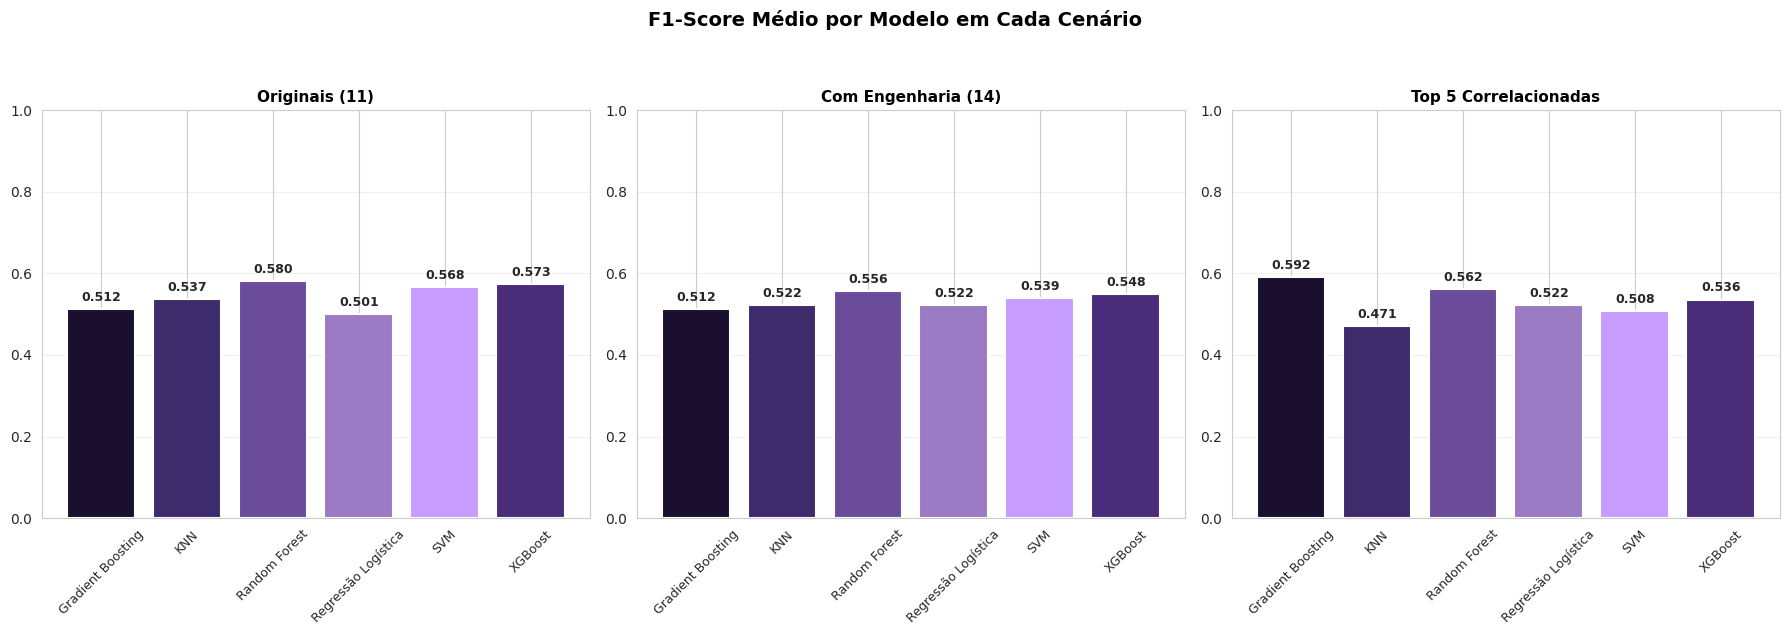

In [40]:
# Gráfico - F1-Score por Modelo (3 cenários)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, cenario in enumerate(cenarios_features.keys()):
    dados = df_resultados[df_resultados['Cenário'] == cenario]
    media_f1 = dados.groupby('Modelo')['F1-Score'].mean()

    # Fix: Use dictionary.get() to retrieve colors by model name
    cores = [cores_modelos.get(model_name, COR_MEDIA) for model_name in media_f1.index]

    bars = axes[i].bar(media_f1.index, media_f1.values,
                       color=cores, edgecolor='white', linewidth=1.5)

    axes[i].set_title(cenario, fontweight='bold', color='black', fontsize=11)
    axes[i].set_ylim(0, 1)
    axes[i].tick_params(axis='x', rotation=45, labelsize=9)
    axes[i].grid(axis='y', alpha=0.3)

    for bar, val in zip(bars, media_f1.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                    f'{val:.3f}', ha='center', fontweight='bold', fontsize=9)

plt.suptitle('F1-Score Médio por Modelo em Cada Cenário',
             fontsize=14, fontweight='bold', color='black', y=1.05)
plt.tight_layout()
plt.show()

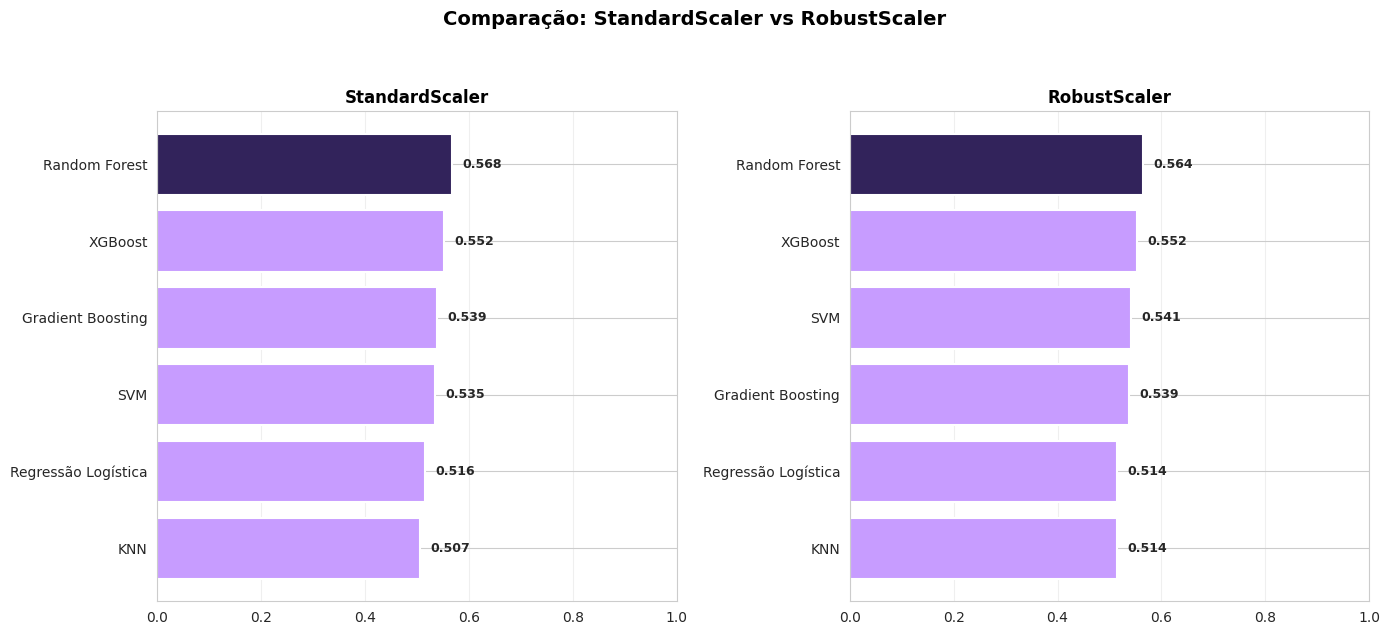

In [41]:
# 5.3: Gráfico - Standard vs Robust Scaler

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for i, escalador in enumerate(['StandardScaler', 'RobustScaler']):
    dados = df_resultados[df_resultados['Escalador'] == escalador]
    media_f1 = dados.groupby('Modelo')['F1-Score'].mean().sort_values(ascending=True)

    cores = [COLORS['bad'] if m != media_f1.idxmax() else COLORS['good']
             for m in media_f1.index]

    bars = axes[i].barh(media_f1.index, media_f1.values,
                        color=cores, edgecolor='white', linewidth=1.5)

    axes[i].set_title(f'{escalador}', fontweight='bold', color='black')
    axes[i].set_xlim(0, 1)
    axes[i].grid(axis='x', alpha=0.3)

    for bar, val in zip(bars, media_f1.values):
        axes[i].text(val + 0.02, bar.get_y() + bar.get_height()/2,
                    f'{val:.3f}', va='center', fontweight='bold', fontsize=9)

plt.suptitle('Comparação: StandardScaler vs RobustScaler',
             fontsize=14, fontweight='bold', color='black', y=1.05)
plt.tight_layout()
plt.show()

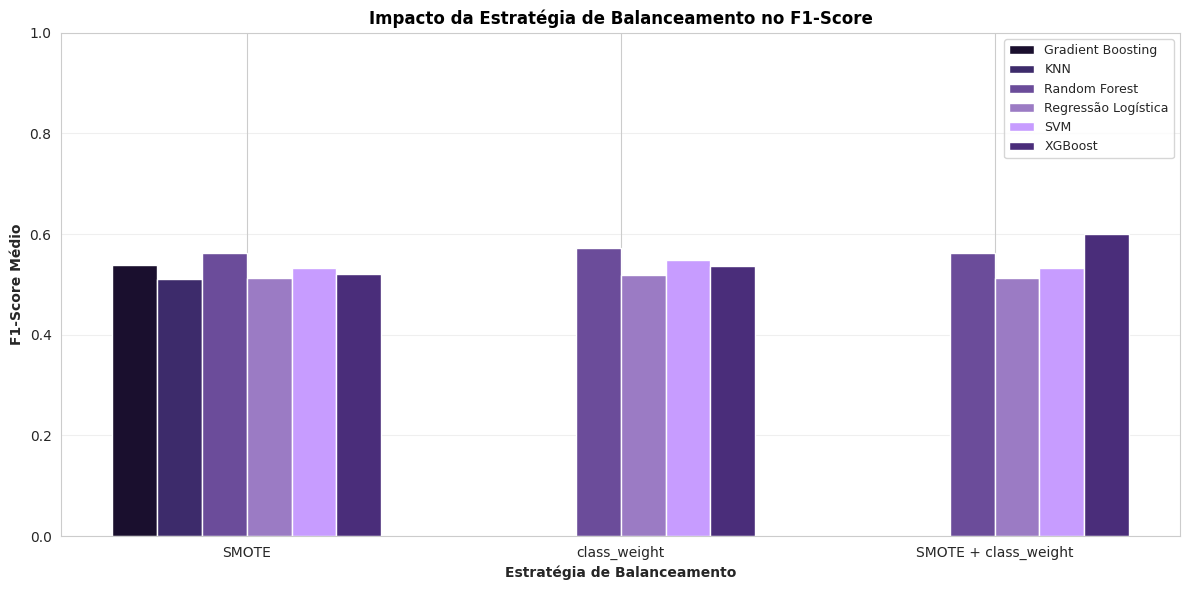

In [42]:
# 5.4: Gráfico - Estratégias de Balanceamento

fig, ax = plt.subplots(figsize=(12, 6))

estrategias_order = ['SMOTE', 'class_weight', 'SMOTE + class_weight']
dados_agg = df_resultados.groupby(['Estratégia', 'Modelo'])['F1-Score'].mean().unstack()

x = np.arange(len(estrategias_order))
width = 0.12

for j, modelo in enumerate(dados_agg.columns):
    valores = [dados_agg.loc[est, modelo] if est in dados_agg.index else 0
               for est in estrategias_order]
    bars = ax.bar(x + j*width - 2.5*width, valores, width,
                  label=modelo, color=cores_modelos.get(modelo, '#7B5BAE'), edgecolor='white')

ax.set_xlabel('Estratégia de Balanceamento', fontweight='bold')
ax.set_ylabel('F1-Score Médio', fontweight='bold')
ax.set_title('Impacto da Estratégia de Balanceamento no F1-Score',
             fontweight='bold', color='black')
ax.set_xticks(x)
ax.set_xticklabels(estrategias_order)
ax.legend(fontsize=9)
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [43]:
print("="*80)
print(" DESEMPENHO POR ESTRATÉGIA DE BALANCEAMENTO")
print("="*80)

estrategias = ['SMOTE', 'class_weight', 'SMOTE + class_weight']

for estrategia in estrategias:
    dados = df_resultados[df_resultados['Estratégia'] == estrategia]
    media_f1 = dados.groupby('Modelo')['F1-Score'].mean()

    print(f"\n Estratégia: {estrategia}")
    print("-"*60)
    print(f"{'Modelo':<25} {'F1-Score':<12}")
    for modelo, f1 in media_f1.sort_values(ascending=False).items():
        print(f"{modelo:<25} {f1:.3f}")

# Melhor estratégia geral
melhor = df_resultados.groupby(['Modelo', 'Estratégia'])['F1-Score'].mean()
top_combinacoes = melhor.nlargest(10)

print("\n" + "="*80)
print(" TOP 10 COMBINAÇÕES (Modelo + Estratégia)")
print("="*80)
print(top_combinacoes)

 DESEMPENHO POR ESTRATÉGIA DE BALANCEAMENTO

 Estratégia: SMOTE
------------------------------------------------------------
Modelo                    F1-Score    
Random Forest             0.563
Gradient Boosting         0.539
SVM                       0.533
XGBoost                   0.520
Regressão Logística       0.513
KNN                       0.510

 Estratégia: class_weight
------------------------------------------------------------
Modelo                    F1-Score    
Random Forest             0.572
SVM                       0.548
XGBoost                   0.537
Regressão Logística       0.518

 Estratégia: SMOTE + class_weight
------------------------------------------------------------
Modelo                    F1-Score    
XGBoost                   0.601
Random Forest             0.563
SVM                       0.533
Regressão Logística       0.513

 TOP 10 COMBINAÇÕES (Modelo + Estratégia)
Modelo             Estratégia          
XGBoost            SMOTE + class_weight    

### Resultado dos top 3 modelos

**Métricas de avaliação**:

 Os desempenhos dos modelos selecionados foram avaliados utilizando múltiplas métricas, cada uma capturando diferentes aspectos:

•	**F1-Score:** essa é a métrica principal, usa a média harmônica entre Precision e Recall, equilibrando as duas métricas, é adequada para datasets que apresentam dados desbalanceados;

•	**Acurácia:** proporção de previsões corretas (tanto positivas quanto negativas) em relação ao total. É uma médrica intuitiva, porém pode enganar, principalmente em datasets desbalanceados;

•	**AUC-ROC** (*Area Under the Receiver Operating Characteristic Curve*): me a capacidade dos modelos de identificar as classes em diferentes thresholds de decisões. Valores próximos de 1, indica que o modelo consegue separar as classes, e se for próximo de 0,5, o modelo é inútil para separar;

•	**Precision:** proporção de verdadeiros positivos em relação a todos os positivos previstos, ou seja, mede a qualidade das respostas do modelo;

•	**Recall** (sensibilidade): proporção de verdadeiros positivos em relação a todos os positivos reais, ou seja, mede a quantidade de casos reais que o modelo conseguiu encontrar.

Foi utilizado conjuntamente, todas essas métricas para ter uma análise abrangente do desempenho dos modelos.


Os 3 modelos com maior desempenho foram os **XGBoost, Gradient Boosting e SVM**. Como pode ser observado na tabela 2, **XGBoost** foi o melhor modelo em *F1-score (0,639)*, mas o **Random Forest** teve a melhor *acurácia (0,917)*. O *SVM* ficou em 3º, mas apresentou um desempenho consistente.

In [44]:
melhores_por_modelo = df_resultados.loc[
    df_resultados.groupby('Modelo')['F1-Score'].idxmax()
].sort_values('F1-Score', ascending=False)

top3 = melhores_por_modelo.head(3)

print("\n🏆 TOP 3 MODELOS:")
print("-"*80)
for i, (_, row) in enumerate(top3.iterrows(), 1):
    print(f"{i}. {row['Modelo']}")
    print(f"   Estratégia: {row['Estratégia']}")
    print(f"   Cenário: {row['Cenário']}")
    print(f"   Escalador: {row['Escalador']}")
    print(f"   F1-Score: {row['F1-Score']:.3f}")
    print(f"   Acurácia: {row['Acurácia']:.3f}")
    print()


🏆 TOP 3 MODELOS:
--------------------------------------------------------------------------------
1. XGBoost
   Estratégia: SMOTE + class_weight
   Cenário: Com Engenharia (14)
   Escalador: StandardScaler
   F1-Score: 0.639
   Acurácia: 0.873

2. Random Forest
   Estratégia: class_weight
   Cenário: Com Engenharia (14)
   Escalador: StandardScaler
   F1-Score: 0.622
   Acurácia: 0.917

3. SVM
   Estratégia: SMOTE
   Cenário: Originais (11)
   Escalador: RobustScaler
   F1-Score: 0.594
   Acurácia: 0.873



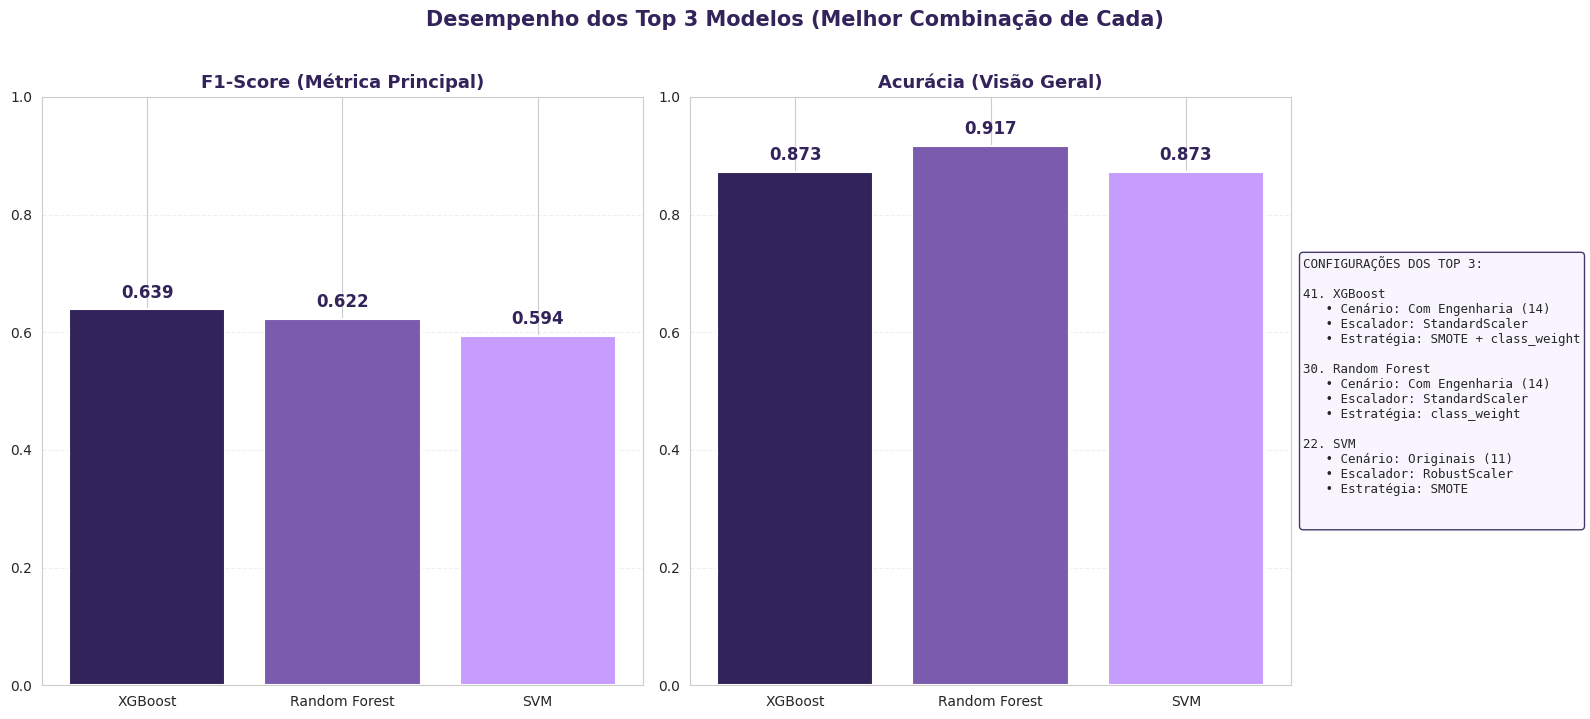


🏆 TOP 3 MODELOS (por F1-Score):
1. XGBoost | F1: 0.639 | AUC: 0.903
2. Random Forest | F1: 0.622 | AUC: 0.901
3. SVM | F1: 0.594 | AUC: 0.908


In [50]:

# ============================================
# GRÁFICO (USANDO O MESMO top3)
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Gráfico 1: F1-Score
cores = [COR_ESCURA, COR_MEDIA, COR_CLARA]
barras_f1 = axes[0].bar(top3['Modelo'], top3['F1-Score'],
                        color=cores, edgecolor='white', linewidth=1.5)

axes[0].set_title('F1-Score (Métrica Principal)',
                  fontweight='bold', color=COR_ESCURA, fontsize=13)
axes[0].set_ylim(0, 1)
axes[0].grid(axis='y', alpha=0.3, linestyle='--')

for bar, val in zip(barras_f1, top3['F1-Score']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.3f}', ha='center', fontweight='bold',
                fontsize=12, color=COR_ESCURA)

# Gráfico 2: Acurácia
barras_acc = axes[1].bar(top3['Modelo'], top3['Acurácia'],
                         color=cores, edgecolor='white', linewidth=1.5)

axes[1].set_title('Acurácia (Visão Geral)',
                  fontweight='bold', color=COR_ESCURA, fontsize=13)
axes[1].set_ylim(0, 1)
axes[1].grid(axis='y', alpha=0.3, linestyle='--')

for bar, val in zip(barras_acc, top3['Acurácia']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.3f}', ha='center', fontweight='bold',
                fontsize=12, color=COR_ESCURA)

# Adicionar caixa com configurações
config_text = "CONFIGURAÇÕES DOS TOP 3:\n\n"
for i, row in top3.iterrows():
    rank = i + 1
    config_text += f"{rank}. {row['Modelo']}\n"
    config_text += f"   • Cenário: {row['Cenário']}\n"
    config_text += f"   • Escalador: {row['Escalador']}\n"
    config_text += f"   • Estratégia: {row['Estratégia']}\n\n"

axes[1].text(1.02, 0.5, config_text,
             transform=axes[1].transAxes, fontsize=9,
             verticalalignment='center',
             bbox=dict(boxstyle='round', facecolor='#F8F4FF',
                       edgecolor=COR_ESCURA, alpha=0.9),
             family='monospace')

plt.suptitle('Desempenho dos Top 3 Modelos (Melhor Combinação de Cada)',
             fontsize=15, fontweight='bold', color=COR_ESCURA, y=1.02)
plt.tight_layout()
plt.show()

# Pega a melhor combinação (maior F1-Score) de cada modelo
melhores = df_resultados.sort_values('F1-Score', ascending=False) \
                        .drop_duplicates(subset=['Modelo']) \
                        .head(3) \
                        .reset_index(drop=True)

print("\n🏆 TOP 3 MODELOS (por F1-Score):")
for i, row in melhores.iterrows():
    print(f"{i+1}. {row['Modelo']} | F1: {row['F1-Score']:.3f} | AUC: {row['AUC-ROC']:.3f}")


In [46]:
# 2. TREINAR OS TOP 3 MODELOS NOVAMENTE

print("\n Retreinando os Top 3 modelos para gerar matrizes...")

modelos_treinados = {}

for idx, row in top3.iterrows():
    modelo_nome = row['Modelo']
    cenario = row['Cenário']
    estrategia = row['Estratégia']
    escalador_nome = row['Escalador']
    melhores_params = row['Melhores Params']

    print(f"\n Treinando: {modelo_nome}")

    # Pegar features do cenário
    if cenario == 'Originais (11)':
        lista_features = ['fixed acidity', 'volatile acidity', 'citric acid',
                          'residual sugar', 'chlorides', 'free sulfur dioxide',
                          'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']
    elif cenario == 'Com Engenharia (14)':
        lista_features = ['fixed acidity', 'volatile acidity', 'citric acid',
                          'residual sugar', 'chlorides', 'free sulfur dioxide',
                          'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol',
                          'alcohol_volatile_ratio', 'sulphates_alcohol_product', 'acidity_balance']
    else:  # Top 5 Correlacionadas
        # Ajuste conforme suas features top 5
        lista_features = ['alcohol', 'volatile acidity', 'sulphates', 'citric acid', 'density']

    X_train_cen = X_train[lista_features]
    X_test_cen = X_test[lista_features]

    # Montar pipeline
    steps = []

    # Adicionar SMOTE se necessário
    if 'SMOTE' in estrategia:
        steps.append(('smote', SMOTE(random_state=42)))

    # Adicionar escalador
    if escalador_nome == 'StandardScaler':
        steps.append(('scaler', StandardScaler()))
    else:
        steps.append(('scaler', RobustScaler()))

    # Criar modelo com melhores parâmetros
    if modelo_nome == 'Random Forest':
        from sklearn.ensemble import RandomForestClassifier
        modelo = RandomForestClassifier(
            n_estimators=melhores_params.get('modelo__n_estimators', 100),
            max_depth=melhores_params.get('modelo__max_depth', 10),
            min_samples_split=melhores_params.get('modelo__min_samples_split', 2),
            class_weight='balanced' if 'class_weight' in estrategia else None,
            random_state=42, n_jobs=-1
        )
    elif modelo_nome == 'KNN':
        from sklearn.neighbors import KNeighborsClassifier
        modelo = KNeighborsClassifier(
            n_neighbors=melhores_params.get('modelo__n_neighbors', 5),
            weights=melhores_params.get('modelo__weights', 'distance'),
            metric=melhores_params.get('modelo__metric', 'euclidean')
        )
    elif modelo_nome == 'Regressão Logística':
        from sklearn.linear_model import LogisticRegression
        modelo = LogisticRegression(
            C=melhores_params.get('modelo__C', 1),
            penalty=melhores_params.get('modelo__penalty', 'l2'),
            solver=melhores_params.get('modelo__solver', 'lbfgs'),
            class_weight='balanced' if 'class_weight' in estrategia else None,
            random_state=42, max_iter=1000
        )
    elif modelo_nome == 'SVM':
        from sklearn.svm import SVC
        modelo = SVC(
            C=melhores_params.get('modelo__C', 1),
            kernel=melhores_params.get('modelo__kernel', 'rbf'),
            gamma=melhores_params.get('modelo__gamma', 'scale'),
            class_weight='balanced' if 'class_weight' in estrategia else None,
            probability=True, random_state=42
        )
    elif modelo_nome == 'XGBoost':
        from xgboost import XGBClassifier
        peso = sum(y_train == 0) / sum(y_train == 1) if 'class_weight' in estrategia else 1
        modelo = XGBClassifier(
            n_estimators=melhores_params.get('modelo__n_estimators', 100),
            max_depth=melhores_params.get('modelo__max_depth', 3),
            learning_rate=melhores_params.get('modelo__learning_rate', 0.1),
            scale_pos_weight=peso if 'class_weight' in estrategia else 1,
            random_state=42, verbosity=0, use_label_encoder=False, eval_metric='logloss'
        )
    elif modelo_nome == 'Gradient Boosting':
        from sklearn.ensemble import GradientBoostingClassifier
        modelo = GradientBoostingClassifier(
            n_estimators=melhores_params.get('modelo__n_estimators', 100),
            max_depth=melhores_params.get('modelo__max_depth', 3),
            learning_rate=melhores_params.get('modelo__learning_rate', 0.1),
            random_state=42
        )

    steps.append(('modelo', modelo))
    pipeline = ImbPipeline(steps)

    # Treinar
    pipeline.fit(X_train_cen, y_train)

    # Prever
    y_pred = pipeline.predict(X_test_cen)

    # Calcular métricas
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    acertos = int(tp + tn)
    erros = int(fp + fn)

    modelos_treinados[modelo_nome] = {
        'pipeline': pipeline,
        'y_pred': y_pred,
        'cm': cm,
        'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp,
        'acertos': acertos,
        'erros': erros,
        'metricas': row
    }

    print(f"   ✅ Treinado! TP={tp}, TN={tn}, FP={fp}, FN={fn}")


 Retreinando os Top 3 modelos para gerar matrizes...

 Treinando: XGBoost
   ✅ Treinado! TP=23, TN=155, FP=22, FN=4

 Treinando: Random Forest
   ✅ Treinado! TP=14, TN=173, FP=4, FN=13

 Treinando: SVM
   ✅ Treinado! TP=19, TN=159, FP=18, FN=8



 GERANDO GRÁFICO DE ACERTOS E ERROS


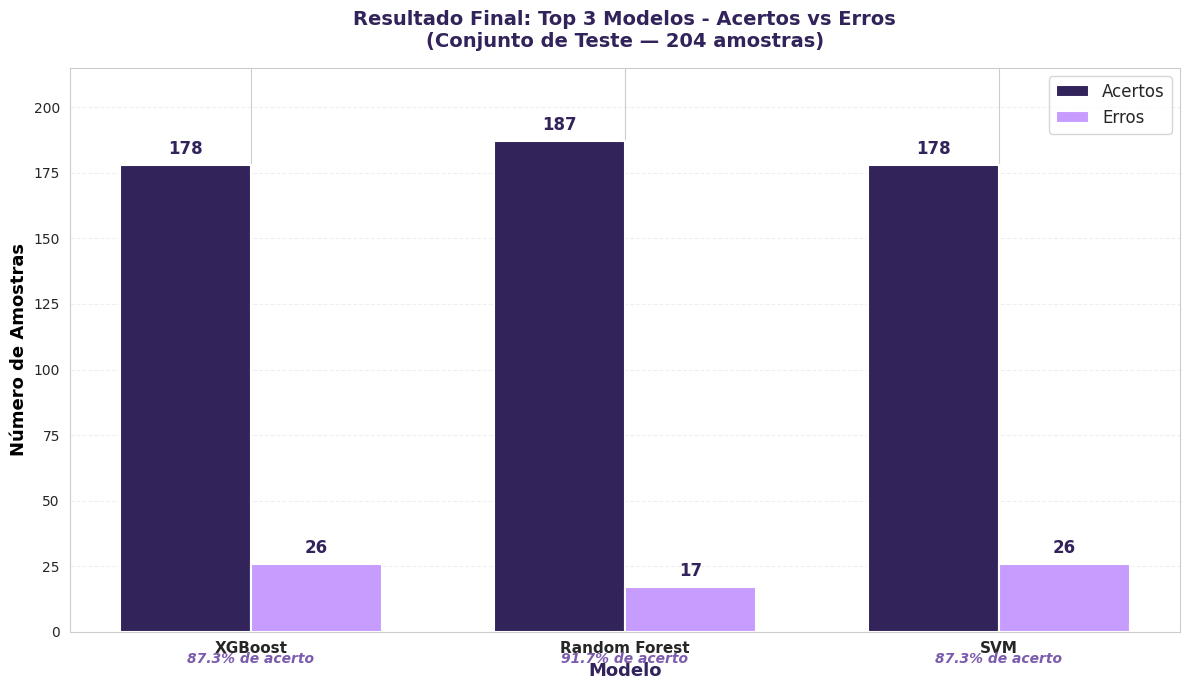

In [47]:
# 4. GRÁFICO DE ACERTOS VS ERROS
# ============================================
print("\n GERANDO GRÁFICO DE ACERTOS E ERROS")

# Preparar dados
nomes_modelos = list(modelos_treinados.keys())
acertos = [modelos_treinados[m]['acertos'] for m in nomes_modelos]
erros = [modelos_treinados[m]['erros'] for m in nomes_modelos]
porcentagem_acerto = [a/(a+e)*100 for a, e in zip(acertos, erros)]

fig, ax = plt.subplots(figsize=(12, 7))

x = np.arange(len(nomes_modelos))
largura = 0.35

barras_acertos = ax.bar(x - largura/2, acertos, largura,
                         label='Acertos', color=COR_ESCURA,
                         edgecolor='white', linewidth=1.5)

barras_erros = ax.bar(x + largura/2, erros, largura,
                       label='Erros', color=COR_CLARA,
                       edgecolor='white', linewidth=1.5)

ax.set_ylabel('Número de Amostras', fontsize=13, fontweight='bold', color='black')
ax.set_xlabel('Modelo', fontsize=13, fontweight='bold', color=COR_ESCURA)
ax.set_title(f'Resultado Final: Top 3 Modelos - Acertos vs Erros\n'
             f'(Conjunto de Teste — {len(y_test)} amostras)',
             fontsize=14, fontweight='bold', color=COR_ESCURA, pad=15)

ax.set_xticks(x)
ax.set_xticklabels(nomes_modelos, fontsize=11, fontweight='bold')
ax.set_ylim(0, max(acertos) * 1.15)
ax.legend(fontsize=12, loc='upper right')
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Adicionar valores nas barras
def adicionar_valores(barras, cor_texto='black'):
    for barra in barras:
        altura = barra.get_height()
        ax.annotate(f'{int(altura)}',
                    xy=(barra.get_x() + barra.get_width() / 2, altura),
                    xytext=(0, 5),
                    textcoords="offset points",
                    ha='center', va='bottom',
                    fontsize=12, fontweight='bold', color=cor_texto)

adicionar_valores(barras_acertos, COR_ESCURA)
adicionar_valores(barras_erros, COR_ESCURA)

# Adicionar porcentagem de acerto abaixo de cada modelo
for i, pct in enumerate(porcentagem_acerto):
    ax.text(i, -max(erros)*0.3, f'{pct:.1f}% de acerto',
            ha='center', va='top', fontsize=10,
            fontweight='bold', color=COR_MEDIA, style='italic')

plt.tight_layout()
plt.show()



 GERANDO MATRIZES DE CONFUSÃO


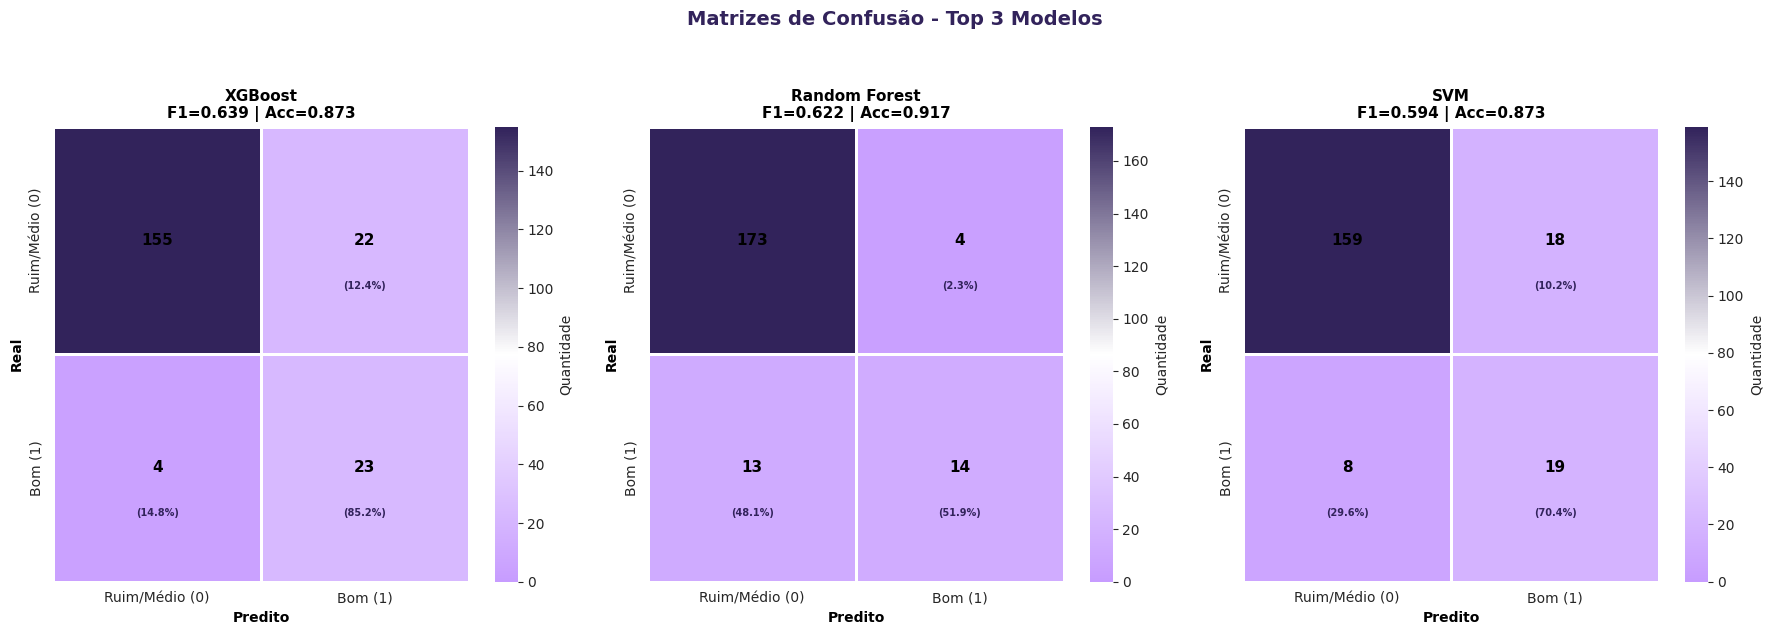

In [48]:
# 3. GERAR MATRIZES DE CONFUSÃO INDIVIDUAIS

print("\n" + "="*80)
print(" GERANDO MATRIZES DE CONFUSÃO")
print("="*80)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, (modelo_nome, dados) in enumerate(modelos_treinados.items()):
    cm = dados['cm']
    metricas = dados['metricas']

    # Calcular porcentagens por linha
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

    # Plotar matriz
    sns.heatmap(cm,
                annot=True,
                fmt='d',
                cmap=cmap_custom, # Corrected from cmap_roxo to cmap_custom
                ax=axes[idx],
                xticklabels=['Ruim/Médio (0)', 'Bom (1)'],
                yticklabels=['Ruim/Médio (0)', 'Bom (1)'],
                cbar_kws={'label': 'Quantidade'},
                linewidths=2,
                linecolor='white',
                vmin=0, vmax=cm.max())

    axes[idx].set_title(f'{modelo_nome}\n'
                        f'F1={metricas["F1-Score"]:.3f} | Acc={metricas["Acurácia"]:.3f}',
                        fontweight='bold', color='black', fontsize=11)
    axes[idx].set_xlabel('Predito', fontweight='bold', fontsize=10, color='black')
    axes[idx].set_ylabel('Real', fontweight='bold', fontsize=10, color='black')

    # Ajustar cor dos números
    for text in axes[idx].texts:
        text.set_color('black')
        text.set_fontweight('bold')
        text.set_fontsize(11)

    # Adicionar porcentagens
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            percent = cm_percent[i, j]
            axes[idx].text(j + 0.5, i + 0.7, f'({percent:.1f}%)',
                          ha='center', va='center', fontsize=7,
                          color=COR_ESCURA, fontweight='bold')

plt.suptitle('Matrizes de Confusão - Top 3 Modelos',
             fontsize=14, fontweight='bold', color=COR_ESCURA, y=1.05)
plt.tight_layout()
plt.show()

In [53]:
# TREINAR OS TOP 3 PARA GERAR AS PROBABILIDADES

modelos_top3 = {}

for idx, row in melhores.iterrows():
    modelo_nome = row['Modelo']
    cenario = row['Cenário']
    estrategia = row['Estratégia']
    escalador_nome = row['Escalador']
    melhores_params = row['Melhores Params']

    print(f"\n Preparando: {modelo_nome}")

    # Pegar features do cenário
    lista_features = cenarios_features[cenario]
    X_train_cen = X_train[lista_features]
    X_test_cen = X_test[lista_features]

    # Montar pipeline
    steps = []
    if 'SMOTE' in estrategia:
        steps.append(('smote', SMOTE(random_state=42)))

    if escalador_nome == 'StandardScaler':
        steps.append(('scaler', StandardScaler()))
    else:
        steps.append(('scaler', RobustScaler()))

    # Criar modelo com melhores parâmetros
    if modelo_nome == 'Random Forest':
        modelo = RandomForestClassifier(
            n_estimators=melhores_params.get('modelo__n_estimators', 100),
            max_depth=melhores_params.get('modelo__max_depth', 10),
            min_samples_split=melhores_params.get('modelo__min_samples_split', 2),
            class_weight='balanced' if 'class_weight' in estrategia else None,
            random_state=42, n_jobs=-1
        )
    elif modelo_nome == 'KNN':
        modelo = KNeighborsClassifier(
            n_neighbors=melhores_params.get('modelo__n_neighbors', 5),
            weights=melhores_params.get('modelo__weights', 'distance'),
            metric=melhores_params.get('modelo__metric', 'euclidean')
        )
    elif modelo_nome == 'Regressão Logística':
        modelo = LogisticRegression(
            C=melhores_params.get('modelo__C', 1),
            penalty=melhores_params.get('modelo__penalty', 'l2'),
            solver=melhores_params.get('modelo__solver', 'lbfgs'),
            class_weight='balanced' if 'class_weight' in estrategia else None,
            random_state=42, max_iter=1000
        )
    elif modelo_nome == 'SVM':
        modelo = SVC(
            C=melhores_params.get('modelo__C', 1),
            kernel=melhores_params.get('modelo__kernel', 'rbf'),
            gamma=melhores_params.get('modelo__gamma', 'scale'),
            class_weight='balanced' if 'class_weight' in estrategia else None,
            probability=True, random_state=42
        )
    elif modelo_nome == 'XGBoost':
        peso = sum(y_train == 0) / sum(y_train == 1) if 'class_weight' in estrategia else 1
        modelo = XGBClassifier(
            n_estimators=melhores_params.get('modelo__n_estimators', 100),
            max_depth=melhores_params.get('modelo__max_depth', 3),
            learning_rate=melhores_params.get('modelo__learning_rate', 0.1),
            scale_pos_weight=peso if 'class_weight' in estrategia else 1,
            random_state=42, verbosity=0, use_label_encoder=False, eval_metric='logloss'
        )
    elif modelo_nome == 'Gradient Boosting':
        modelo = GradientBoostingClassifier(
            n_estimators=melhores_params.get('modelo__n_estimators', 100),
            max_depth=melhores_params.get('modelo__max_depth', 3),
            learning_rate=melhores_params.get('modelo__learning_rate', 0.1),
            random_state=42
        )

    steps.append(('modelo', modelo))
    pipeline = ImbPipeline(steps)

    # Treinar
    pipeline.fit(X_train_cen, y_train)

    # Obter PROBABILIDADES (essencial para a curva ROC!)
    y_proba = pipeline.predict_proba(X_test_cen)[:, 1]

    # Calcular AUC
    auc = roc_auc_score(y_test, y_proba)

    modelos_top3[modelo_nome] = {
        'y_proba': y_proba,
        'auc': auc,
        'config': row
    }

    print(f"AUC-ROC: {auc:.3f}")


 Preparando: XGBoost
AUC-ROC: 0.903

 Preparando: Random Forest
AUC-ROC: 0.901

 Preparando: SVM
AUC-ROC: 0.908


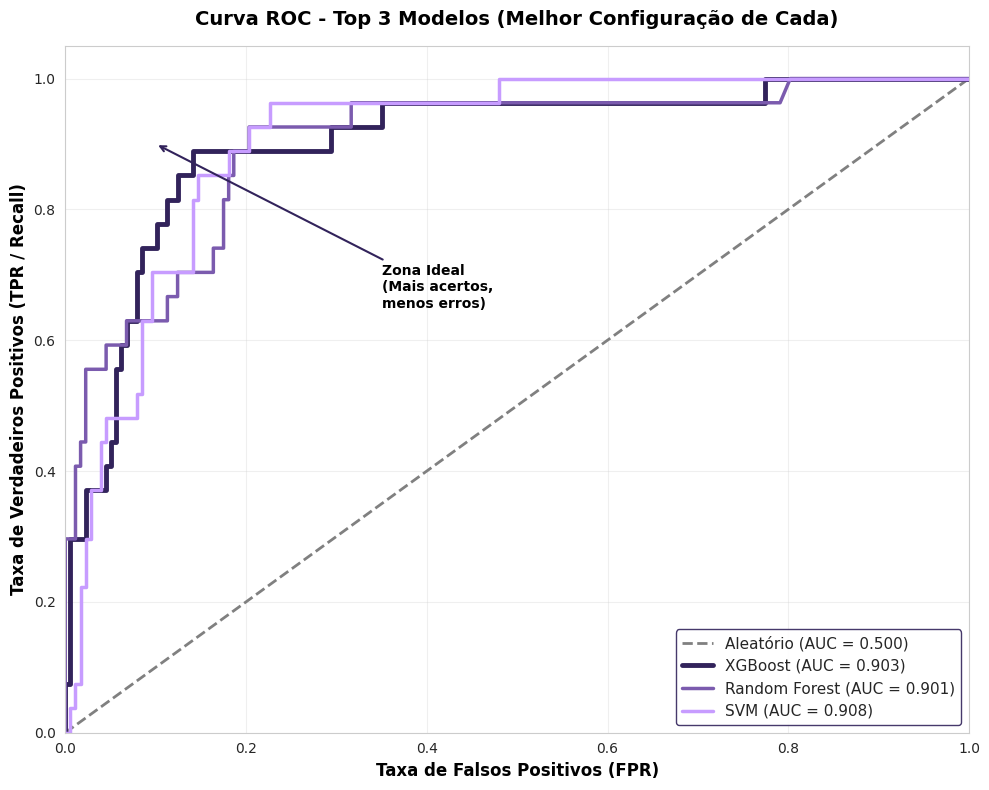

📊 RESUMO - CURVA ROC TOP 3
Modelo                    AUC-ROC      F1-Score     Estratégia               
--------------------------------------------------------------------------------
XGBoost                   0.903        0.639        SMOTE + class_weight     
Random Forest             0.901        0.622        class_weight             
SVM                       0.908        0.594        SMOTE + class_weight     

🏆 CAMPEÃO DA AUC-ROC: XGBoost
   AUC-ROC: 0.903


In [54]:
# PLOTAR A CURVA ROC

fig, ax = plt.subplots(figsize=(10, 8))

# Linha de base (chute aleatório)
ax.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--',
        label='Aleatório (AUC = 0.500)')

# Cores para os 3 modelos (do melhor para o pior)
cores_top3 = [COR_ESCURA, COR_MEDIA, COR_CLARA]

# Plotar cada modelo
for (modelo_nome, dados), cor in zip(modelos_top3.items(), cores_top3):
    fpr, tpr, thresholds = roc_curve(y_test, dados['y_proba'])
    auc = dados['auc']

    # Destacar o campeão com linha mais grossa
    lw = 3.5 if modelo_nome == list(modelos_top3.keys())[0] else 2.5

    ax.plot(fpr, tpr, color=cor, lw=lw,
            label=f'{modelo_nome} (AUC = {auc:.3f})')

# Formatação
ax.set_xlabel('Taxa de Falsos Positivos (FPR)', fontsize=12, fontweight='bold', color='black')
ax.set_ylabel('Taxa de Verdadeiros Positivos (TPR / Recall)', fontsize=12, fontweight='bold', color='black')
ax.set_title('Curva ROC - Top 3 Modelos (Melhor Configuração de Cada)',
             fontsize=14, fontweight='bold', color='black', pad=15)

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.legend(loc="lower right", fontsize=11, framealpha=0.9,
          facecolor='white', edgecolor=COR_ESCURA)
ax.grid(True, alpha=0.3)

# Destacar a zona ideal (canto superior esquerdo)
ax.annotate('Zona Ideal\n(Mais acertos,\nmenos erros)',
            xy=(0.1, 0.9), xytext=(0.35, 0.65),
            fontsize=10, color='black', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=COR_ESCURA, lw=1.5))

plt.tight_layout()
plt.show()

# ============================================
# TABELA RESUMO
# ============================================print("\n" + "="*80)
print("📊 RESUMO - CURVA ROC TOP 3")
print("="*80)
print(f"{'Modelo':<25} {'AUC-ROC':<12} {'F1-Score':<12} {'Estratégia':<25}")
print("-"*80)

for modelo_nome, dados in modelos_top3.items():
    config = dados['config']
    print(f"{modelo_nome:<25} {dados['auc']:<12.3f} {config['F1-Score']:<12.3f} {config['Estratégia']:<25}")

print("="*80)

campeao = list(modelos_top3.keys())[0]
print(f"\n🏆 CAMPEÃO DA AUC-ROC: {campeao}")
print(f"   AUC-ROC: {modelos_top3[campeao]['auc']:.3f}")
print("="*80)

Discussão sobre o Trade-off entre os modelos

In [56]:
# PREPARAR OS DADOS (14 FEATURES)
X = df[features_com_engenharia]
y = df['quality_binary']

# ============================================
# CONFIGURAR OS MODELOS (MELHORES CONFIGURAÇÕES)

# XGBoost (SMOTE + StandardScaler + scale_pos_weight)
peso_xgb = sum(y == 0) / sum(y == 1)
pipeline_xgb = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('modelo', XGBClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.1,
        scale_pos_weight=peso_xgb, random_state=42, verbosity=0, eval_metric='logloss'
    ))
])

# Random Forest (StandardScaler + class_weight)
pipeline_rf = ImbPipeline([
    ('scaler', StandardScaler()),
    ('modelo', RandomForestClassifier(
        n_estimators=200, max_depth=10, class_weight='balanced',
        random_state=42, n_jobs=-1
    ))
])

modelos = {'XGBoost': pipeline_xgb, 'Random Forest': pipeline_rf}


In [57]:
# LOOP DE VALIDAÇÃO CRUZADA (3 FOLDS)

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

resultados_cv = []

print("="*80)
print("ANÁLISE DE VARIABILIDADE ENTRE FOLDS (3-FOLD CV)")
print("="*80)

for nome_modelo, pipeline in modelos.items():
    print(f"\n Modelo: {nome_modelo}")
    print("-"*80)

    f1_scores = []
    recalls = []
    precisions = []
    fns = [] # Falsos Negativos (para responder o professor)

    for i, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        X_train_fold, X_val_fold = X.iloc[train_idx], X.iloc[val_idx]
        y_train_fold, y_val_fold = y.iloc[train_idx], y.iloc[val_idx]

        # Treinar
        pipeline.fit(X_train_fold, y_train_fold)
        y_pred_fold = pipeline.predict(X_val_fold)

        # Métricas
        f1 = f1_score(y_val_fold, y_pred_fold)
        rec = recall_score(y_val_fold, y_pred_fold)
        prec = precision_score(y_val_fold, y_pred_fold, zero_division=0)

        # Matriz de confusão
        tn, fp, fn, tp = confusion_matrix(y_val_fold, y_pred_fold).ravel()

        f1_scores.append(f1)
        recalls.append(rec)
        precisions.append(prec)
        fns.append(fn)

        print(f"  Fold {i+1}: F1={f1:.3f} | Recall={rec:.3f} | Precision={prec:.3f} | Falsos Negativos={fn}")

    # Estatísticas gerais
    resultados_cv.append({
        'Modelo': nome_modelo,
        'F1_Mean': np.mean(f1_scores),
        'F1_Std': np.std(f1_scores),
        'Recall_Mean': np.mean(recalls),
        'Recall_Std': np.std(recalls),
        'Precision_Mean': np.mean(precisions),
        'Precision_Std': np.std(precisions),
        'FN_Mean': np.mean(fns)
    })

df_cv = pd.DataFrame(resultados_cv)

print("\n" + "="*80)
print("RESUMO DA VARIABILIDADE (MÉDIA ± DESVIO PADRÃO)")
print("="*80)
print(df_cv.to_string(index=False))
print("="*80)

ANÁLISE DE VARIABILIDADE ENTRE FOLDS (3-FOLD CV)

 Modelo: XGBoost
--------------------------------------------------------------------------------
  Fold 1: F1=0.462 | Recall=0.587 | Precision=0.380 | Falsos Negativos=19
  Fold 2: F1=0.412 | Recall=0.444 | Precision=0.385 | Falsos Negativos=25
  Fold 3: F1=0.588 | Recall=0.761 | Precision=0.479 | Falsos Negativos=11

 Modelo: Random Forest
--------------------------------------------------------------------------------
  Fold 1: F1=0.456 | Recall=0.391 | Precision=0.545 | Falsos Negativos=28
  Fold 2: F1=0.400 | Recall=0.289 | Precision=0.650 | Falsos Negativos=32
  Fold 3: F1=0.578 | Recall=0.565 | Precision=0.591 | Falsos Negativos=20

RESUMO DA VARIABILIDADE (MÉDIA ± DESVIO PADRÃO)
       Modelo  F1_Mean   F1_Std  Recall_Mean  Recall_Std  Precision_Mean  Precision_Std   FN_Mean
      XGBoost 0.487382 0.074085     0.597424    0.129392        0.414783       0.045762 18.333333
Random Forest 0.477825 0.074245     0.415137    0.114062  

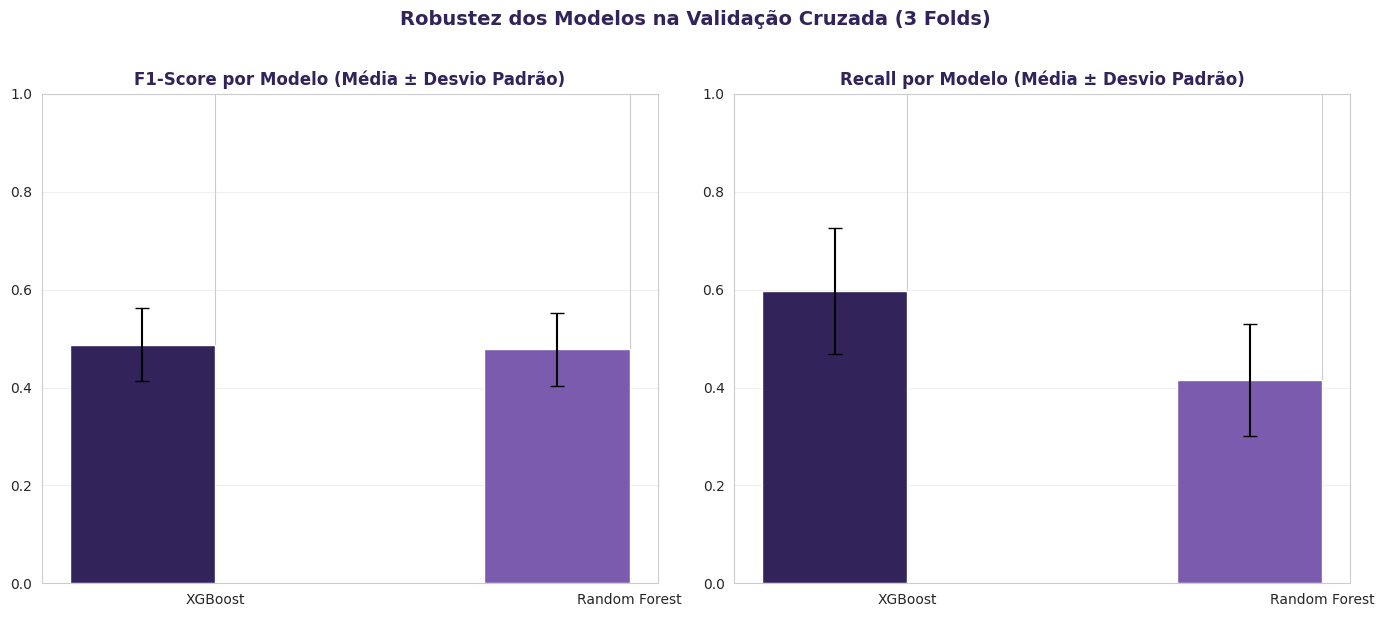

In [58]:
# GRÁFICO DE VARIABILIDADE (BOXPLOT OU BARRAS COM ERRO)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

modelos_nomes = df_cv['Modelo']
x = np.arange(len(modelos_nomes))
largura = 0.35

# Gráfico 1: F1-Score
axes[0].bar(x - largura/2, df_cv['F1_Mean'], largura,
            yerr=df_cv['F1_Std'], color=[COR_ESCURA, COR_MEDIA],
            edgecolor='white', capsize=5, label='F1-Score')
axes[0].set_title('F1-Score por Modelo (Média ± Desvio Padrão)',
                  fontweight='bold', color=COR_ESCURA)
axes[0].set_xticks(x)
axes[0].set_xticklabels(modelos_nomes)
axes[0].set_ylim(0, 1)
axes[0].grid(axis='y', alpha=0.3)

# Gráfico 2: Recall (O mais importante para o professor)
axes[1].bar(x - largura/2, df_cv['Recall_Mean'], largura,
            yerr=df_cv['Recall_Std'], color=[COR_ESCURA, COR_MEDIA],
            edgecolor='white', capsize=5, label='Recall')
axes[1].set_title('Recall por Modelo (Média ± Desvio Padrão)',
                  fontweight='bold', color=COR_ESCURA)
axes[1].set_xticks(x)
axes[1].set_xticklabels(modelos_nomes)
axes[1].set_ylim(0, 1)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Robustez dos Modelos na Validação Cruzada (3 Folds)',
             fontsize=14, fontweight='bold', color=COR_ESCURA, y=1.02)
plt.tight_layout()
plt.show()

 Importância das variáveis

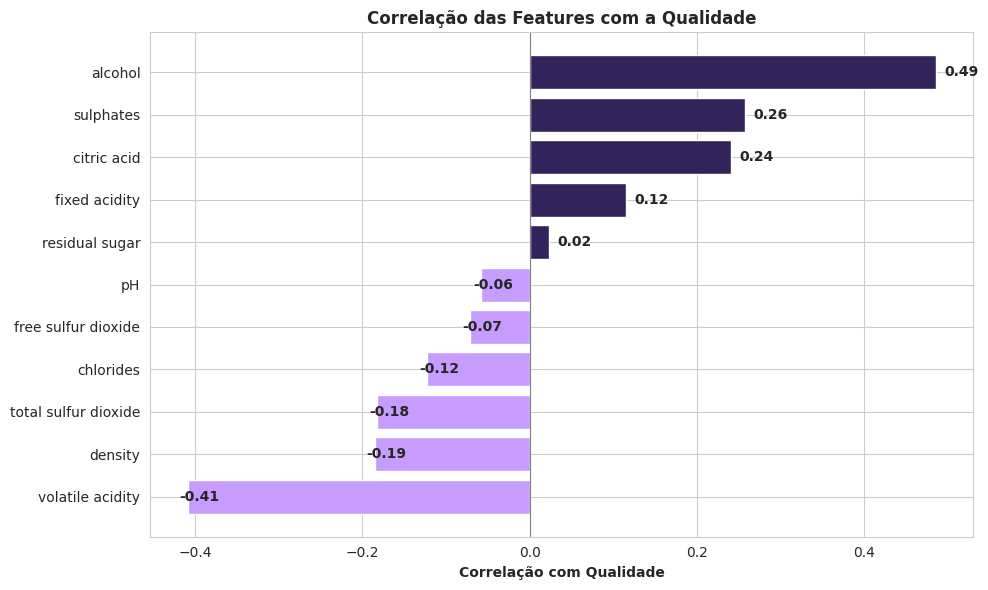


    INSIGHTS DAS CORRELAÇÕES:
      POSITIVAS (aumentam qualidade):
      - alcohol (álcool): maior teor alcoólico = melhor qualidade
      - sulphates (sulfatos): mais sulfatos = melhor qualidade
      - citric acid (ácido cítrico): mais ácido cítrico = melhor qualidade

    - NEGATIVAS (diminuem qualidade):
      - volatile acidity (acidez volátil): mais acidez volátil = pior qualidade
      - density (densidade): mais densidade = pior qualidade
      - total sulfur dioxide: mais SO₂ total = pior qualidade


In [61]:
# Vizualizar correlação com qualidade
fig, ax = plt.subplots(figsize=(10, 6))
colors_corr = [COLORS['good'] if c > 0 else COLORS['bad'] for c in corr_with_quality]
ax.barh(corr_with_quality.index, corr_with_quality.values,
        color=colors_corr, edgecolor='white')
ax.axvline(0, color='gray', linewidth=0.8)
ax.set_xlabel('Correlação com Qualidade', fontweight='bold')
ax.set_title('Correlação das Features com a Qualidade',
              fontweight='bold', fontsize=12)

# Adicionar valores nas barras
for i, (feat, val) in enumerate(corr_with_quality.items()):
    ax.text(val + 0.01 * np.sign(val), i, f'{val:.2f}',
            va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print('\n    INSIGHTS DAS CORRELAÇÕES:')
print('      POSITIVAS (aumentam qualidade):')
print('      - alcohol (álcool): maior teor alcoólico = melhor qualidade')
print('      - sulphates (sulfatos): mais sulfatos = melhor qualidade')
print('      - citric acid (ácido cítrico): mais ácido cítrico = melhor qualidade')
print('\n    - NEGATIVAS (diminuem qualidade):')
print('      - volatile acidity (acidez volátil): mais acidez volátil = pior qualidade')
print('      - density (densidade): mais densidade = pior qualidade')
print('      - total sulfur dioxide: mais SO₂ total = pior qualidade')

### ETAPA 6 - Interpretação dos Resultados


 6.1: Variáveis com Maior Influência na Qualidade

 Melhor combinação: XGBoost
   Cenário: Com Engenharia (14)
   F1-Score: 0.639


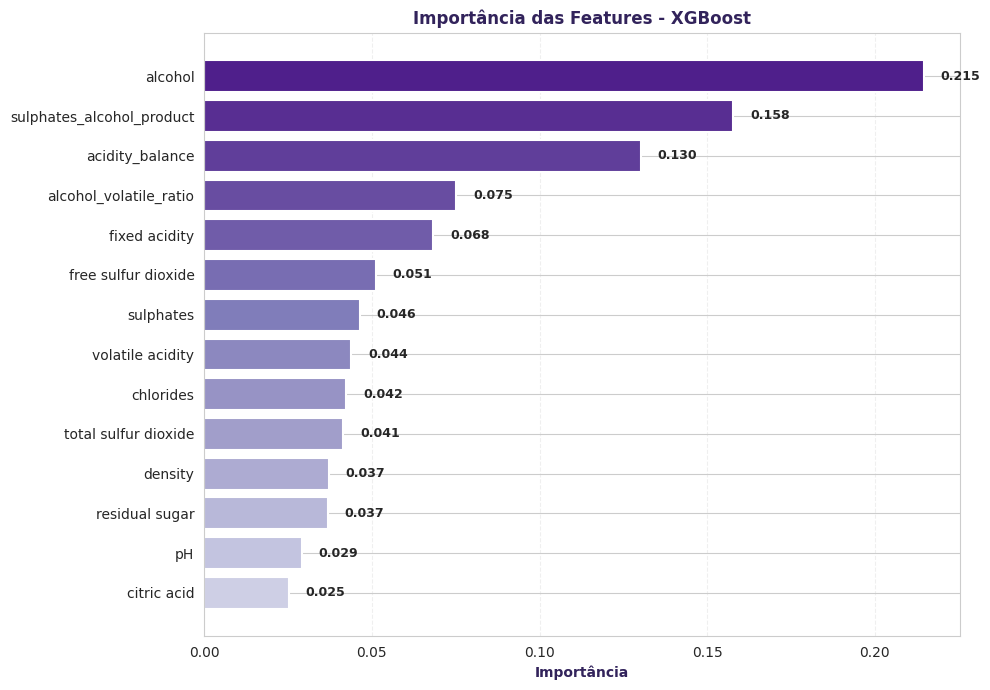


 RANKING DAS FEATURES MAIS IMPORTANTES:
------------------------------------------------------------
   11. alcohol: 0.2146
   13. sulphates_alcohol_product: 0.1578
   14. acidity_balance: 0.1302
   12. alcohol_volatile_ratio: 0.0751
   1. fixed acidity: 0.0683


In [60]:
# 6.1: Identificar Variáveis Mais Influentes
print("\n 6.1: Variáveis com Maior Influência na Qualidade")

melhor_combinacao = df_resultados.loc[df_resultados['F1-Score'].idxmax()]
print(f"\n Melhor combinação: {melhor_combinacao['Modelo']}")
print(f"   Cenário: {melhor_combinacao['Cenário']}")
print(f"   F1-Score: {melhor_combinacao['F1-Score']:.3f}")

if melhor_combinacao['Modelo'] in ['Random Forest', 'Gradient Boosting', 'XGBoost']:
    modelo_nome = melhor_combinacao['Modelo']
    cenario = melhor_combinacao['Cenário']
    lista_features = cenarios_features[cenario]

    X_train_best = X_train[lista_features]
    X_test_best = X_test[lista_features]

    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train_best)

    if 'SMOTE' in melhor_combinacao['Estratégia']:
        smote = SMOTE(random_state=42)
        X_train_sc, y_train_sc = smote.fit_resample(X_train_sc, y_train)
    else:
        y_train_sc = y_train

    if modelo_nome == 'Random Forest':
        modelo_import = RandomForestClassifier(
            n_estimators=melhor_combinacao['Melhores Params'].get('modelo__n_estimators', 100),
            max_depth=melhor_combinacao['Melhores Params'].get('modelo__max_depth', 10),
            random_state=42, n_jobs=-1
        )
    elif modelo_nome == 'XGBoost':
        modelo_import = XGBClassifier(
            n_estimators=melhor_combinacao['Melhores Params'].get('modelo__n_estimators', 100),
            max_depth=melhor_combinacao['Melhores Params'].get('modelo__max_depth', 3),
            random_state=42, verbosity=0
        )
    else:
        modelo_import = GradientBoostingClassifier(
            n_estimators=melhor_combinacao['Melhores Params'].get('modelo__n_estimators', 100),
            max_depth=melhor_combinacao['Melhores Params'].get('modelo__max_depth', 3),
            random_state=42
        )

    modelo_import.fit(X_train_sc, y_train_sc)

    importancias = modelo_import.feature_importances_

    df_imp = pd.DataFrame({
        'Feature': lista_features,
        'Importância': importancias
    }).sort_values('Importância', ascending=True)

    fig, ax = plt.subplots(figsize=(10, 7))
    n = len(df_imp)
    cores_grad = plt.cm.Purples(np.linspace(0.3, 0.9, n))

    bars = ax.barh(df_imp['Feature'], df_imp['Importância'],
                   color=cores_grad, edgecolor='white', linewidth=1.5)

    ax.set_xlabel('Importância', fontweight='bold', color=COR_ESCURA)
    ax.set_title(f'Importância das Features - {modelo_nome}',
                 fontweight='bold', color=COR_ESCURA, fontsize=12)
    ax.grid(axis='x', alpha=0.3, linestyle='--')

    for bar, val in zip(bars, df_imp['Importância']):
        ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9, fontweight='bold')

    plt.tight_layout()
    plt.show()

    print("\n RANKING DAS FEATURES MAIS IMPORTANTES:")
    print("-"*60)
    for i, row in df_imp.sort_values('Importância', ascending=False).head(5).iterrows():
        print(f"   {i+1}. {row['Feature']}: {row['Importância']:.4f}")


In [69]:
# Implicações para o Processo de Produção

print("\n" + "="*80)
print(" 6.2: Implicações para o Processo de Produção")
print("="*80)

print("""
 CONCLUSÕES E RECOMENDAÇÕES:

1️⃣ FATOR MAIS CRÍTICO: TEOR ALCOÓLICO (alcohol)
    → Correlação positiva mais forte com a qualidade
    → Recomendação: Monitorar e otimizar a fermentação para atingir
      teores alcoólicos adequados (acima de 11%)

2️⃣  FATOR MAIS PREJUDICIAL: ACIDEZ VOLÁTIL (volatile acidity)
    → Correlação negativa mais forte
    → Recomendação: Controle rigoroso da contaminação por acetobacter,
      que transforma etanol em ácido acético (vinagre)

3️⃣  FATORES SECUNDÁRIOS POSITIVOS:
    → Sulphates (sulfatos): atuam como conservantes e antioxidantes
    → Citric acid (ácido cítrico): contribui para frescor e sabor
    → Recomendação: Adição controlada de sulfatos e manutenção
      de níveis adequados de ácido cítrico

4️⃣  IMPACTO DO MODELO NA INDÚSTRIA:
    → O modelo pode ser usado como ferramenta de TRIAGEM inicial
    → Reduz custos de análise sensorial (sommeliers)
    → Permite controle de qualidade em tempo real na produção
    → É importante ressaltar que esses modelos não substituem a avaliação
      sensorial humana, apenas a complementam. Pois, aspectos como harmonização,
      aroma e preferências, precisam das experiências dos especialistas.

5️⃣  LIMITAÇÕES IDENTIFICADAS:
    → Dataset desbalanceado (apenas ~13.5% de vinhos bons)
    → Qualidade é parcialmente subjetiva (avaliação humana)
    → Features físico-químicas explicam apenas parte da qualidade
    → Recomendação: Coletar mais dados de vinhos de alta qualidade
      e considerar variáveis sensoriais adicionais

6️⃣  PRÓXIMOS PASSOS:
    → Implementar o modelo em sistema de produção
    → Coletar feedback contínuo dos sommeliers
    → Retreinar o modelo periodicamente com novos dados
    → Expandir para previsão de notas específicas (3-9)
""")

print("="*80)
print("✅ TECH CHALLENGE CONCLUÍDO COM SUCESSO!")
print("="*80)


 6.2: Implicações para o Processo de Produção

 CONCLUSÕES E RECOMENDAÇÕES:

1️⃣ FATOR MAIS CRÍTICO: TEOR ALCOÓLICO (alcohol)
    → Correlação positiva mais forte com a qualidade
    → Recomendação: Monitorar e otimizar a fermentação para atingir
      teores alcoólicos adequados (acima de 11%)

2️⃣  FATOR MAIS PREJUDICIAL: ACIDEZ VOLÁTIL (volatile acidity)
    → Correlação negativa mais forte
    → Recomendação: Controle rigoroso da contaminação por acetobacter,
      que transforma etanol em ácido acético (vinagre)

3️⃣  FATORES SECUNDÁRIOS POSITIVOS:
    → Sulphates (sulfatos): atuam como conservantes e antioxidantes
    → Citric acid (ácido cítrico): contribui para frescor e sabor
    → Recomendação: Adição controlada de sulfatos e manutenção
      de níveis adequados de ácido cítrico

4️⃣  IMPACTO DO MODELO NA INDÚSTRIA:
    → O modelo pode ser usado como ferramenta de TRIAGEM inicial
    → Reduz custos de análise sensorial (sommeliers)
    → Permite controle de qualidade em temp